In [23]:
import utils
import numpy as np
import pandas as pd
import os
import re
from matplotlib.pyplot import cm
import matplotlib.pyplot as plt
import seaborn as sns # Loads in the theme

pd.set_option('future.no_silent_downcasting', True)
#pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', 20)
#pd.set_option('display.width', 1000)

In [24]:
# Make output folder
output_dir = os.path.join('..','..','plots','behavioural', 'objective_performance')
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

In [25]:
# Preparation
pilot_analysis = False
split_dataset = False
plot_range = [0, 6]

if pilot_analysis:
    raw_output_path = '/Volumes/project/3025011.02/pilot_data/phd_1_task/experiment_output/behavioural_files_pilot_2'
    unique_subject_ids = [802,803,804,805,806,808,809,811,813,814,815]
    unique_sessions = [1]
else:
    raw_output_path = '/Volumes/project/3025011.02/raw/'
    unique_subject_ids = [5, 10, 14, 15, 16, 20, 22, 23, 25, 28, 29, 37, 38]#[5, 10, 13, 14, 15, 16, 20, 22, 23, 25, 27, 28, 29, 30, 32, 37]
    unique_sessions = [2, 3, 4]
    if unique_sessions != [1]:
        split_dataset = True

combined_results_dataframe = utils.import_functions.main(raw_output_path, unique_subject_ids, unique_sessions, pilot_analysis, remove_reversals=False)
#combined_results_dataframe.to_csv(os.path.join(output_dir, 'combined_results_kenneth.csv'), index=False, sep=';')

['/Volumes/project/3025011.02/raw/sub-005/ses-mri02/beh/behavioural_output_sub-005_session-02_skyra_2025-03-14_11-00-23.csv', '/Volumes/project/3025011.02/raw/sub-005/ses-mri03/beh/behavioural_output_sub-005_session-03_skyra_2025-03-21_15-48-02.csv', '/Volumes/project/3025011.02/raw/sub-005/ses-mri04/beh/behavioural_output_sub-005_session-04_skyra_2025-03-28_15-50-17.csv', '/Volumes/project/3025011.02/raw/sub-010/ses-mri02/beh/behavioural_output_sub-010_session-02_skyra_2025-03-13_11-21-05.csv', '/Volumes/project/3025011.02/raw/sub-010/ses-mri03/beh/behavioural_output_sub-010_session-03_skyra_2025-03-19_11-41-24.csv', '/Volumes/project/3025011.02/raw/sub-010/ses-mri04/beh/behavioural_output_sub-010_session-04_skyra_2025-03-25_15-18-37.csv', '/Volumes/project/3025011.02/raw/sub-014/ses-mri02/beh/behavioural_output_sub-014_session-02_skyra_2025-04-01_16-44-40.csv', '/Volumes/project/3025011.02/raw/sub-014/ses-mri03/beh/behavioural_output_sub-014_session-03_skyra_2025-04-08_10-36-56.csv',

# Analysis
First, we'll look at the reaction time. A plot with all the RT's and average will do.
Second we will look at the percentage of correct answers.
Lastly, we will be looking at a win-stay lose shift to see when behaviour stabilises after a shift in reward contingency.

In [26]:
# Count amount of subplots necessary based on subject_id's and sessions
## Finds unique values
unique_subject_ids = combined_results_dataframe['subject_id'].unique()
unique_sessions = combined_results_dataframe['session'].unique()

## Calculates the number of subplots needed
n_rows = len(unique_subject_ids)
n_cols = len(unique_sessions)
n_subplots = len(unique_sessions) * len(unique_subject_ids)

### Split the dataframe
So that combined_results_dataframe has the results you want to analyse but the combined_results_dataframe_all_sessions includes the 1st session as well

In [27]:
if split_dataset:
    combined_results_dataframe_all_sessions = combined_results_dataframe
    combined_results_dataframe = combined_results_dataframe[combined_results_dataframe['session'] != 'session-01']

# Objectively correct answer binned after every reversal
Sorted for valence

In [28]:
# Create a dataframe with objectively correct responses up to 12 trials since reversal
unique_stimuli_types = combined_results_dataframe['stimuli_type'].unique()
row_index = 0
# Create new plots with different intervals that also contain the 50% trials
mapping = {0: 'subject_id', 1: 'stimuli_type', 2: 'valence', 3: 0, 4: 1, 5: 2, 6: 3, 7: 4, 8: 5, 9: 6, 10: 7, 11: 8, 12: 9, 13: 10}
group_name = 'valence'
unique_group_types = combined_results_dataframe[group_name].unique()


all_reversals_dataframe = utils.analysis_functions.find_reversals_in_dataframe(combined_results_dataframe,
                                                                             unique_subject_ids, unique_stimuli_types,
                                                                             group_name, plot_range, mapping)
print(all_reversals_dataframe)

      subject_id  trial  stimuli_type  probability_condition  reversal valence
0        sub-005      8             1                     20     False   angry
1        sub-005     11             1                     20     False   angry
2        sub-005     12             1                     20     False   angry
3        sub-005     14             1                     20     False   angry
4        sub-005     15             1                     20     False   angry
...          ...    ...           ...                    ...       ...     ...
22871    sub-037    659             2                     20      True   happy
22872    sub-037    660             2                     20     False   happy
22873    sub-037    661             2                     20     False   happy
22874    sub-037    662             2                     20     False   happy
22875    sub-037    666             2                     20     False   happy

[22876 rows x 6 columns]
0    subject_id stimuli_ty

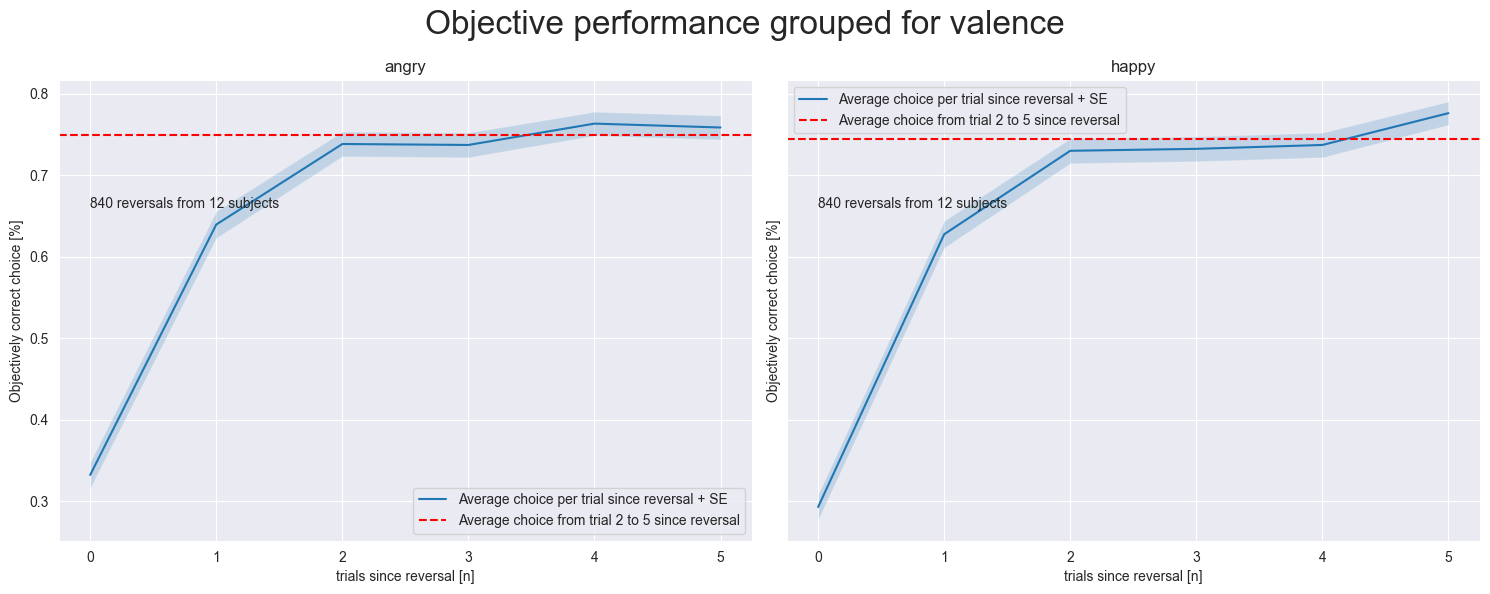

In [29]:
# Prepare the DataFrame by setting 'stimuli_type' as the index temporarily
df = all_reversals_dataframe

subject_counts = len(df['subject_id'].unique())

# Count the number of times both conditions were shown
group_counts = df['valence'].value_counts()

# We are not using 'subject_id', so let's exclude it from our calculations
df = df.drop(columns=['subject_id'])
df = df.drop(columns=['stimuli_type'])

# Calculate the mean and standard deviation for each timepoint and stimuli_type
means = df.groupby(['valence']).mean()
means_overall = means.iloc[:, 2:]
average_choice_after_reversal_total = means_overall.mean(axis=1).tolist()

stds = df.groupby(['valence']).sem()

# Plotting
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 6), sharex=True, sharey=True) # Adjust based on the number of stimuli_types
axs = axs.flatten() # Flatten to iterate easily

fig.suptitle('Objective performance grouped for valence', fontsize=24, y=0.982)

congruency_list = df['valence'].unique()

congruency_types = means.index
for i, congruency_type in enumerate(congruency_types):
    # Timepoints are the column names converted to integers for x-axis values
    timepoints = list(range(plot_range[0], plot_range[1]))
    mean_values = means.loc[congruency_type]
    std_values = stds.loc[congruency_type]

    axs[i].plot(timepoints, mean_values, label='Average choice per trial since reversal + SE')
    axs[i].fill_between(timepoints, mean_values - std_values, mean_values + std_values, alpha=0.2)
    axs[i].axhline((average_choice_after_reversal_total[i]), color='r', linestyle='--', label='Average choice from trial 2 to 5 since reversal')
    #axs[i].plot(probability_dataframe_pivoted[i+1].dropna())
    axs[i].set_title(f'{congruency_list[i]}')
    axs[i].set_xlabel('trials since reversal [n]')
    axs[i].set_ylabel('Objectively correct choice [%]')
    axs[i].text(0, 0.66, f'{group_counts[congruency_type]} reversals from {subject_counts} subjects', fontsize=10)
    axs[i].legend()
    axs[i].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'objective_performance_grouped_for_valence.pdf'))
plt.show()

# Now the same but split for congruency

In [30]:
# Create new plots with different intervals that also contain the 50% trials
mapping = {0: 'subject_id', 1: 'stimuli_type', 2: 'congruency', 3: 0, 4: 1, 5: 2, 6: 3, 7: 4, 8: 5, 9: 6}
group_name = 'congruency'
unique_group_types = combined_results_dataframe[group_name].unique()


all_reversals_dataframe = utils.analysis_functions.find_reversals_in_dataframe(combined_results_dataframe,
                                                                             unique_subject_ids, unique_stimuli_types,
                                                                             'congruency', plot_range, mapping)
print(all_reversals_dataframe)

      subject_id  trial  stimuli_type  probability_condition  reversal  \
0        sub-005      8             1                     20     False   
1        sub-005     11             1                     20     False   
2        sub-005     12             1                     20     False   
3        sub-005     14             1                     20     False   
4        sub-005     15             1                     20     False   
...          ...    ...           ...                    ...       ...   
22871    sub-037    659             2                     20      True   
22872    sub-037    660             2                     20     False   
22873    sub-037    661             2                     20     False   
22874    sub-037    662             2                     20     False   
22875    sub-037    666             2                     20     False   

        congruency  
0        congruent  
1        congruent  
2        congruent  
3      incongruent  
4     

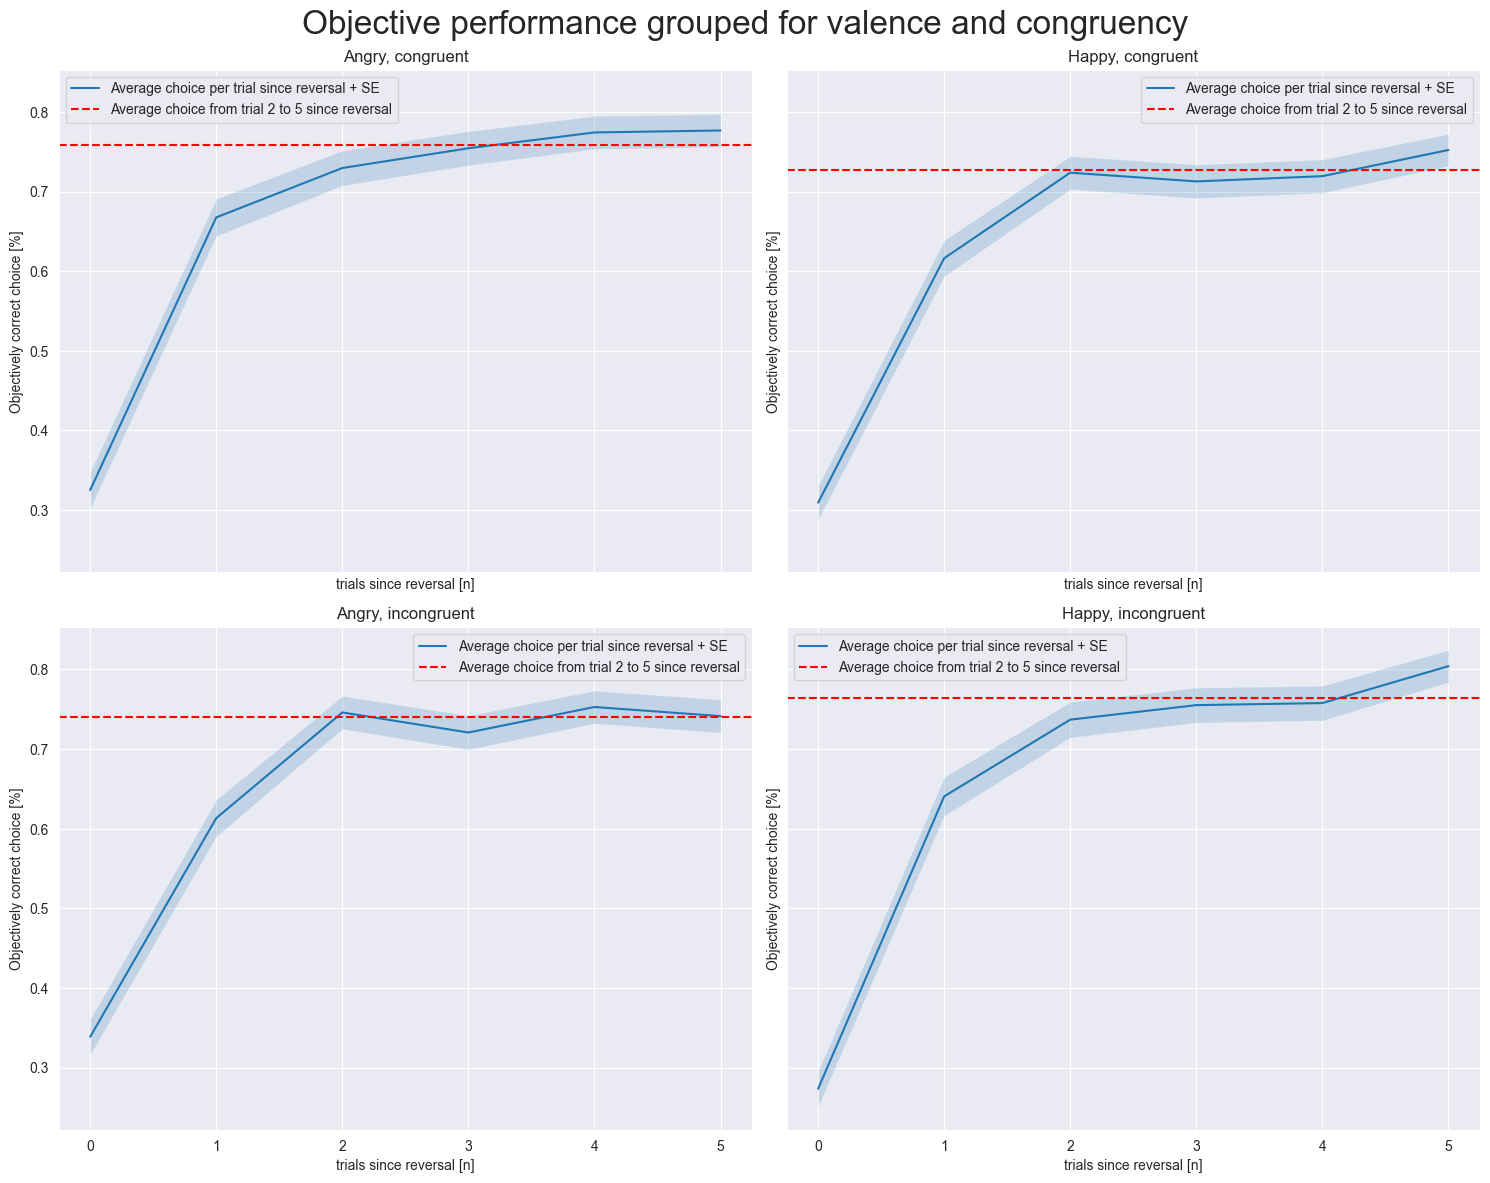

In [31]:
# Prepare the DataFrame by setting 'stimuli_type' as the index temporarily
df = all_reversals_dataframe

# We are not using 'subject_id', so let's exclude it from our calculations
df = df.drop(columns=['subject_id'])

# Calculate the mean and standard deviation for each timepoint and stimuli_type
means = df.groupby(['congruency', 'stimuli_type']).mean()
means_overall = means.iloc[:, 2:]
average_choice_after_reversal_total = means_overall.mean(axis=1).tolist()

stds = df.groupby(['congruency', 'stimuli_type']).sem()

# Plotting
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(15, 12), sharex=True, sharey=True) # Adjust based on the number of stimuli_types
axs = axs.flatten() # Flatten to iterate easily

fig.suptitle('Objective performance grouped for valence and congruency', fontsize=24, y=0.982)

congruency_list = df['congruency'].unique()
stimuli_list = df['stimuli_type'].unique()
stimuli_types_list = ['Angry', 'Angry', 'Happy', 'Happy']

congruency_types = means.index
for i, congruency_type in enumerate(congruency_types):
    # Timepoints are the column names converted to integers for x-axis values
    timepoints = list(range(plot_range[0], plot_range[1]))
    mean_values = means.loc[congruency_type]
    std_values = stds.loc[congruency_type]

    axs[i].plot(timepoints, mean_values, label='Average choice per trial since reversal + SE')
    axs[i].fill_between(timepoints, mean_values - std_values, mean_values + std_values, alpha=0.2)
    axs[i].axhline((average_choice_after_reversal_total[i]), color='r', linestyle='--', label='Average choice from trial 2 to 5 since reversal')
    #axs[i].plot(probability_dataframe_pivoted[i+1].dropna())
    axs[i].set_title(f'{stimuli_types_list[congruency_type[1]]}, {congruency_type[0]}')
    axs[i].set_xlabel('trials since reversal [n]')
    axs[i].set_ylabel('Objectively correct choice [%]')
    axs[i].legend()
    axs[i].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'objective_performance_grouped_for_valence_and_congruency.pdf'))
plt.show()

# Plotting just the responses
As a check to see if giving the two types of responses was equally as difficult

In [32]:
# Create new plots with different intervals that also contain the 50% trials
mapping = {0: 'subject_id', 1: 'stimuli_type', 2: 'response', 3: 0, 4: 1, 5: 2, 6: 3, 7: 4, 8: 5, 9: 6, 10: 7, 11: 8, 12: 9, 13: 10}
group_name = 'response'
unique_group_types = combined_results_dataframe[group_name].unique()


all_reversals_dataframe = utils.analysis_functions.find_reversals_in_dataframe(combined_results_dataframe,
                                                                             unique_subject_ids, unique_stimuli_types,
                                                                             group_name, plot_range, mapping)
print(all_reversals_dataframe)

      subject_id  trial  stimuli_type  probability_condition  reversal  \
0        sub-005      8             1                     20     False   
1        sub-005     11             1                     20     False   
2        sub-005     12             1                     20     False   
3        sub-005     14             1                     20     False   
4        sub-005     15             1                     20     False   
...          ...    ...           ...                    ...       ...   
22871    sub-037    659             2                     20      True   
22872    sub-037    660             2                     20     False   
22873    sub-037    661             2                     20     False   
22874    sub-037    662             2                     20     False   
22875    sub-037    666             2                     20     False   

      response  
0           up  
1           up  
2           up  
3         down  
4         down  
...      

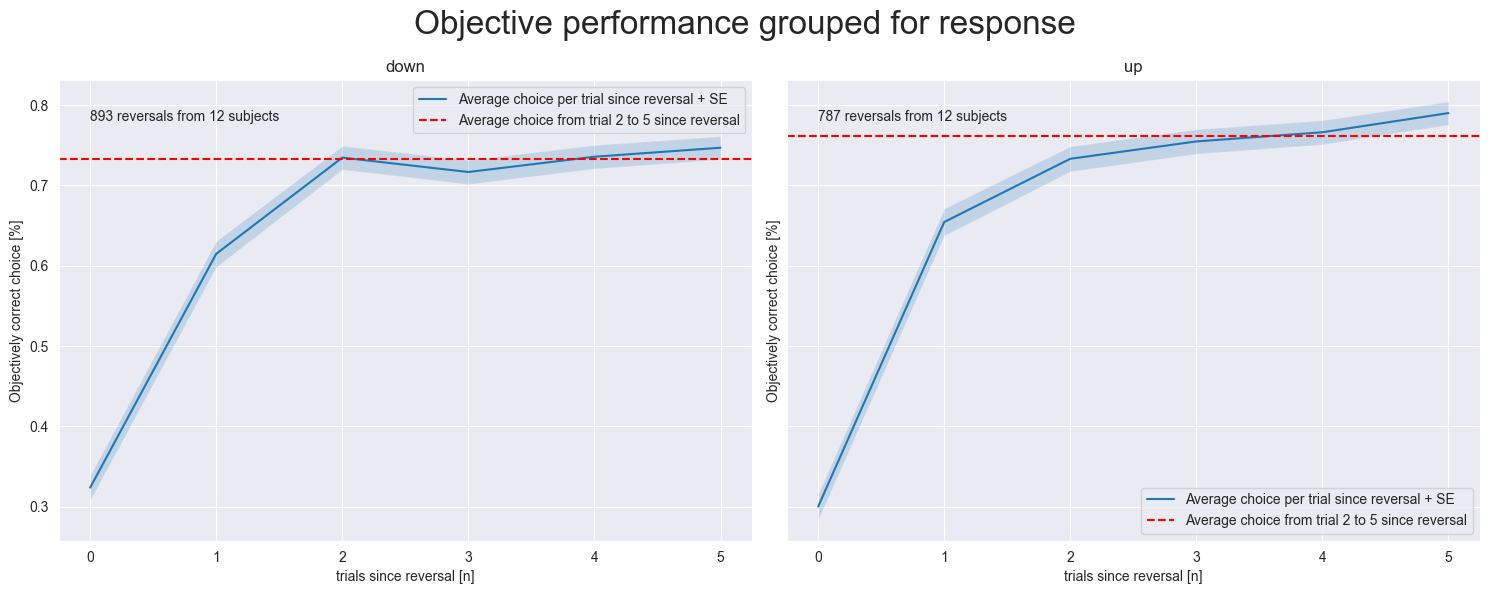

In [33]:
# Prepare the DataFrame by setting 'stimuli_type' as the index temporarily
df = all_reversals_dataframe

subject_counts = len(df['subject_id'].unique())

# Count the number of times both conditions were shown
group_counts = df['response'].value_counts()

# We are not using 'subject_id', so let's exclude it from our calculations
df = df.drop(columns=['subject_id'])
df = df.drop(columns=['stimuli_type'])

# Calculate the mean and standard deviation for each timepoint and stimuli_type
means = df.groupby(['response']).mean()
means_overall = means.iloc[:, 2:]
average_choice_after_reversal_total = means_overall.mean(axis=1).tolist()

stds = df.groupby(['response']).sem()

# Plotting
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 6), sharex=True, sharey=True) # Adjust based on the number of stimuli_types
axs = axs.flatten() # Flatten to iterate easily

fig.suptitle('Objective performance grouped for response', fontsize=24, y=0.982)

congruency_list = df['response'].unique()

congruency_types = means.index
for i, congruency_type in enumerate(congruency_types):
    # Timepoints are the column names converted to integers for x-axis values
    timepoints = list(range(plot_range[0], plot_range[1]))
    mean_values = means.loc[congruency_type]
    std_values = stds.loc[congruency_type]

    axs[i].plot(timepoints, mean_values, label='Average choice per trial since reversal + SE')
    axs[i].fill_between(timepoints, mean_values - std_values, mean_values + std_values, alpha=0.2)
    axs[i].axhline((average_choice_after_reversal_total[i]), color='r', linestyle='--', label='Average choice from trial 2 to 5 since reversal')
    #axs[i].plot(probability_dataframe_pivoted[i+1].dropna())
    axs[i].set_title(f'{congruency_list[i]}')
    axs[i].set_xlabel('trials since reversal [n]')
    axs[i].set_ylabel('Objectively correct choice [%]')
    axs[i].text(0, 0.78, f'{group_counts[congruency_type]} reversals from {subject_counts} subjects', fontsize=10)
    axs[i].legend()
    axs[i].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'objective_performance_grouped_for_response.pdf'))
plt.show()

# Now plot subplots for the responses and congruency
To see whether giving one type of response interacted with congruency, also as a check

In [34]:
# Create new plots with different intervals that also contain the 50% trials
group_name_1 = 'congruency'
group_name_2 = 'response'
initial_columns = {0: 'stimuli_type', 1: 'subject_id', 2: group_name_2, 3: group_name_1}
# Append the plot range to the existing dictionary
mapping = initial_columns.copy()
mapping.update({k+4: v for k, v in enumerate(plot_range)})

dataframe = utils.analysis_functions.find_reversals_in_dataframe(combined_results_dataframe,
                                                                             unique_subject_ids, unique_stimuli_types,
                                                                             group_name_1, plot_range, mapping, group_name_2)
print(dataframe)

      subject_id  trial  stimuli_type  probability_condition  reversal  \
0        sub-005      8             1                     20     False   
1        sub-005     11             1                     20     False   
2        sub-005     12             1                     20     False   
3        sub-005     14             1                     20     False   
4        sub-005     15             1                     20     False   
...          ...    ...           ...                    ...       ...   
22871    sub-037    659             2                     20      True   
22872    sub-037    660             2                     20     False   
22873    sub-037    661             2                     20     False   
22874    sub-037    662             2                     20     False   
22875    sub-037    666             2                     20     False   

        congruency response  
0        congruent       up  
1        congruent       up  
2        congruent   

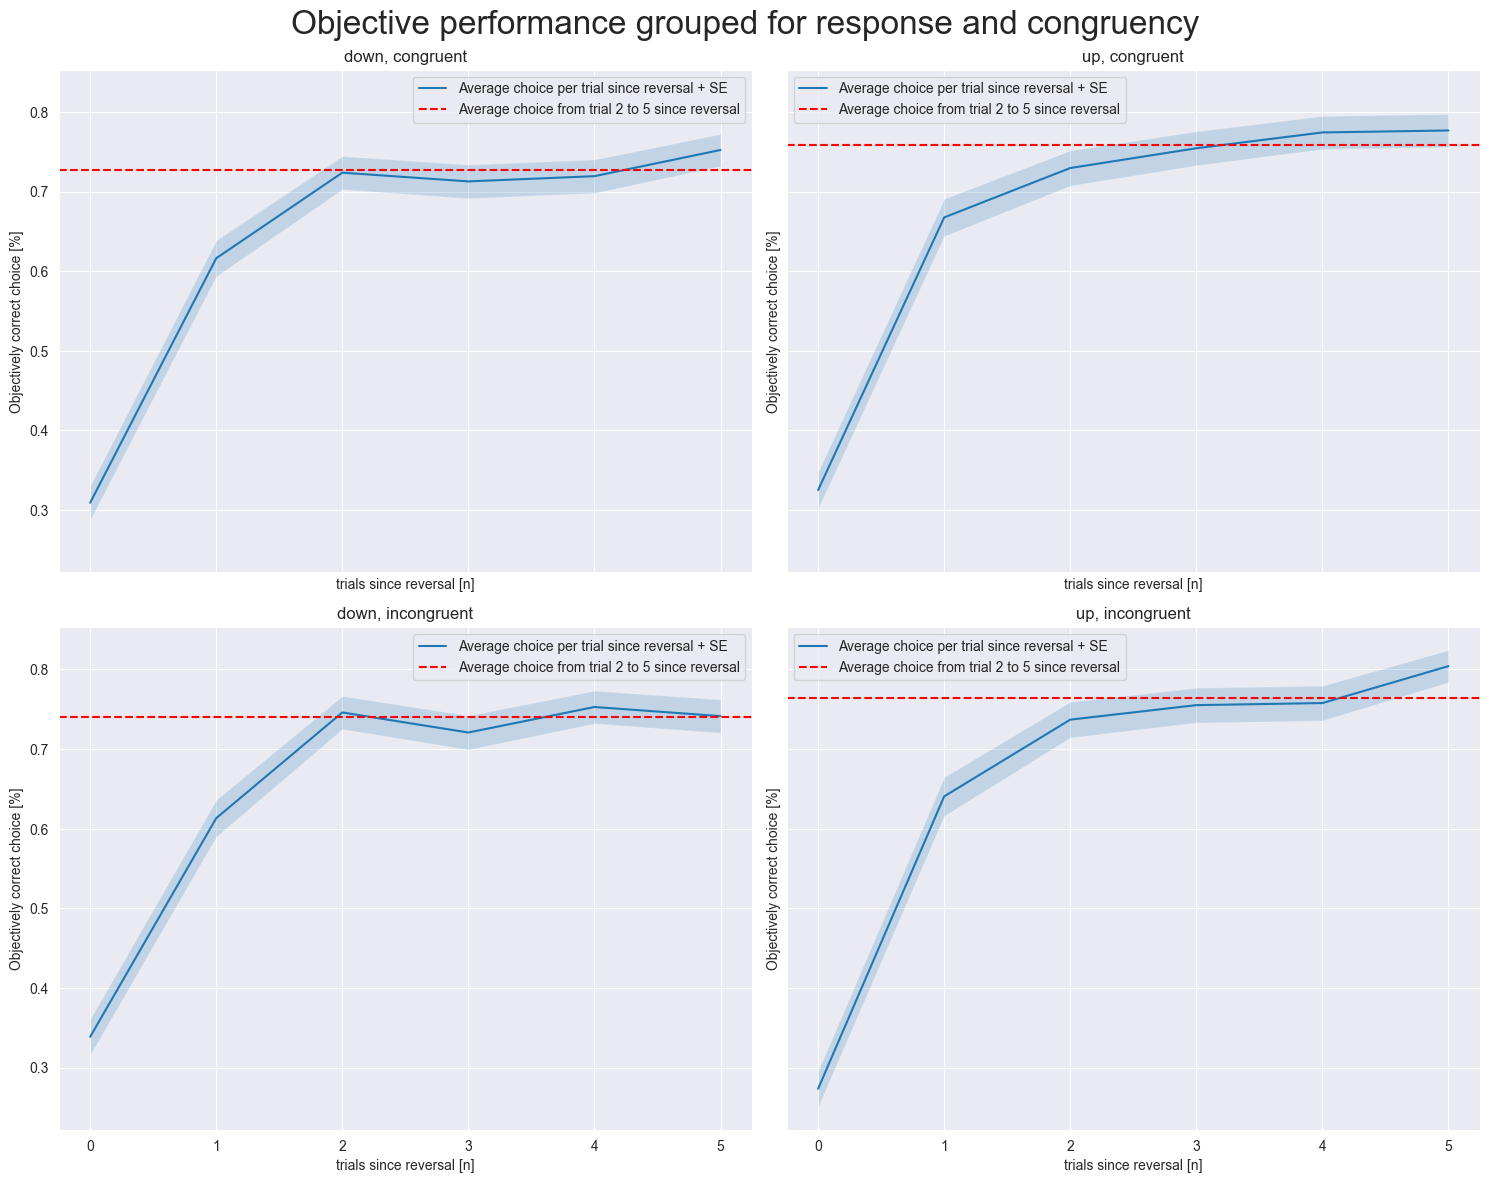

In [35]:
# Prepare the DataFrame by setting 'stimuli_type' as the index temporarily
df = dataframe

# We are not using 'subject_id', so let's exclude it from our calculations
df = df.drop(columns=['subject_id', 'stimuli_type'])

# Calculate the mean and standard deviation for each timepoint and stimuli_type
means = df.groupby(['congruency', 'response']).mean()
means_overall = means.iloc[:, 2:]
average_choice_after_reversal_total = means_overall.mean(axis=1).tolist()

stds = df.groupby(['congruency', 'response']).sem()

# Plotting
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(15, 12), sharex=True, sharey=True) # Adjust based on the number of stimuli_types
axs = axs.flatten() # Flatten to iterate easily

fig.suptitle('Objective performance grouped for response and congruency', fontsize=24, y=0.982)

congruency_list = df['congruency'].unique()
volatility_list = df['response'].unique()

congruency_types = means.index
for i, congruency_type in enumerate(congruency_types):
    if congruency_type != 'undefined':
        # Timepoints are the column names converted to integers for x-axis values
        timepoints = list(range(plot_range[0], plot_range[1]))
        mean_values = means.loc[congruency_type]
        std_values = stds.loc[congruency_type]

        axs[i].plot(timepoints, mean_values, label='Average choice per trial since reversal + SE')
        axs[i].fill_between(timepoints, mean_values - std_values, mean_values + std_values, alpha=0.2)
        axs[i].axhline((average_choice_after_reversal_total[i]), color='r', linestyle='--', label='Average choice from trial 2 to 5 since reversal')
        #axs[i].plot(probability_dataframe_pivoted[i+1].dropna())
        axs[i].set_title(f'{congruency_type[1]}, {congruency_type[0]}')
        axs[i].set_xlabel('trials since reversal [n]')
        axs[i].set_ylabel('Objectively correct choice [%]')
        axs[i].legend()
        axs[i].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'objective_performance_grouped_for_response_and_congruency.pdf'))
plt.show()

# Objectively correct answers binned around a reversal
Starting 12 trials before the reversal and ending 4 after.

In [36]:
# Create new plots with different intervals that also contain the 50% trials
objectively_correct_answers_per_reversal_block = pd.DataFrame()
adjusted_plot_range = [plot_range[0] - plot_range[1] + 1, plot_range[1]]

all_reversals_dataframe = utils.analysis_functions.find_reversals_in_dataframe(combined_results_dataframe,
                                                                             unique_subject_ids, unique_stimuli_types,
                                                                             group_name, adjusted_plot_range, mapping)
print(all_reversals_dataframe)

      subject_id  trial  stimuli_type  probability_condition  reversal  \
0        sub-005      8             1                     20     False   
1        sub-005     11             1                     20     False   
2        sub-005     12             1                     20     False   
3        sub-005     14             1                     20     False   
4        sub-005     15             1                     20     False   
...          ...    ...           ...                    ...       ...   
22871    sub-037    659             2                     20      True   
22872    sub-037    660             2                     20     False   
22873    sub-037    661             2                     20     False   
22874    sub-037    662             2                     20     False   
22875    sub-037    666             2                     20     False   

      response  
0           up  
1           up  
2           up  
3         down  
4         down  
...      

# Subplots for incongruent and congruent reversals

In [37]:
# Create new plots with different intervals that also contain the 50% trials
mapping = {0: 'subject_id', 1: 'stimuli_type', 2: 'congruency', 3: 0, 4: 1, 5: 2, 6: 3, 7: 4, 8: 5, 9: 6}
group_name = 'congruency'
session_name = 'session'
unique_group_types = combined_results_dataframe[group_name].unique()


all_reversals_dataframe = utils.analysis_functions.find_reversals_in_dataframe(combined_results_dataframe,
                                                                             unique_subject_ids, unique_stimuli_types,
                                                                             group_name, plot_range, mapping, session_name)
print(all_reversals_dataframe)

      subject_id  trial  stimuli_type  probability_condition  reversal  \
0        sub-005      8             1                     20     False   
1        sub-005     11             1                     20     False   
2        sub-005     12             1                     20     False   
3        sub-005     14             1                     20     False   
4        sub-005     15             1                     20     False   
...          ...    ...           ...                    ...       ...   
22871    sub-037    659             2                     20      True   
22872    sub-037    660             2                     20     False   
22873    sub-037    661             2                     20     False   
22874    sub-037    662             2                     20     False   
22875    sub-037    666             2                     20     False   

        congruency     session  
0        congruent  session-02  
1        congruent  session-02  
2        con

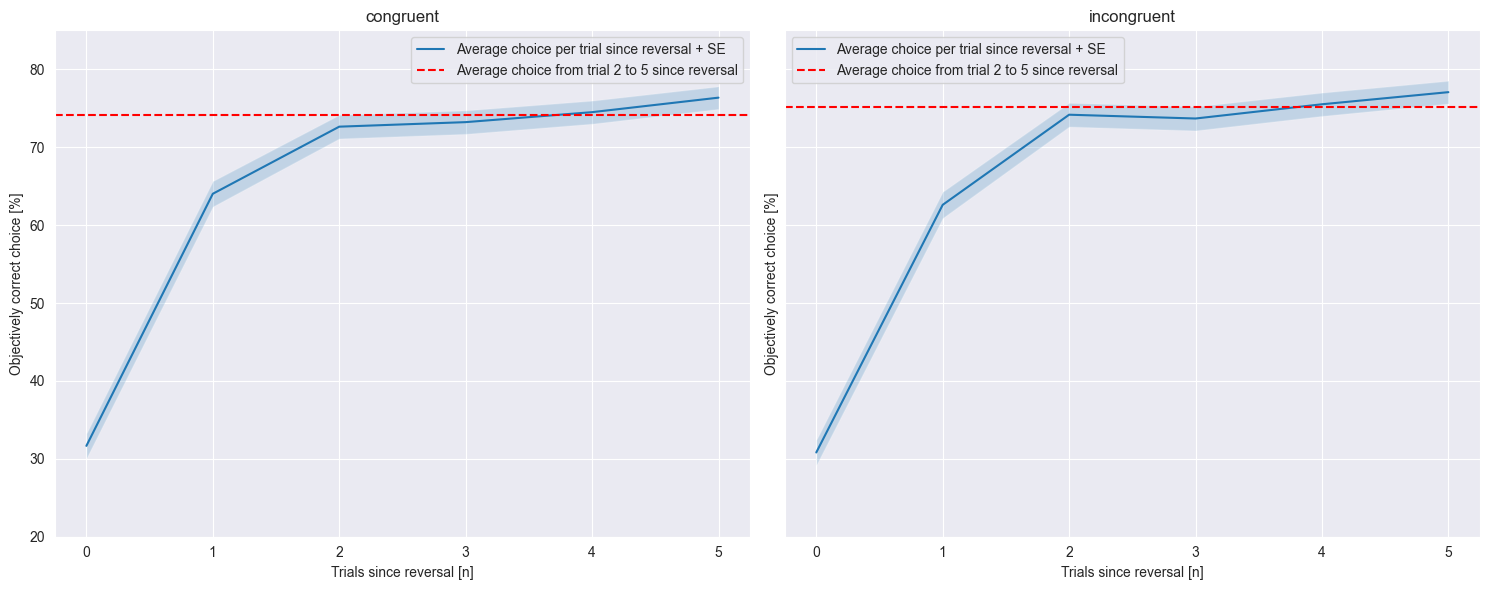

In [38]:
# Prepare the DataFrame by setting 'stimuli_type' as the index temporarily
df = all_reversals_dataframe.set_index('congruency')

subject_counts = len(df['subject_id'].unique())

# Count the number of times both conditions were shown
group_counts = df.index.value_counts()

# We are not using 'subject_id', so let's exclude it from our calculations
df = df.drop(columns=['subject_id'])
df = df.drop(columns=['stimuli_type'])
df = df.drop(columns=['session'])

# Calculate the mean and standard deviation for each timepoint and stimuli_type
means = df.groupby('congruency').mean()
means = means*100
means_overall = means.iloc[:, 2:]
average_choice_after_reversal_total = means_overall.mean(axis=1).tolist()
stds = df.groupby('congruency').sem()
stds = stds * 100

# Plotting
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 6), sharex=False, sharey=True) # Adjust based on the number of stimuli_types
axs = axs.flatten() # Flatten to iterate easily

#fig.suptitle('Objective performance grouped for congruency', fontsize=24, y=0.982)

congruency_list = all_reversals_dataframe['congruency'].unique()

congruency_types = means.index
for i, congruency_type in enumerate(congruency_types):
    if congruency_type != 'undefined':
        # Timepoints are the column names converted to integers for x-axis values
        timepoints = list(range(plot_range[0], plot_range[1]))
        mean_values = means.loc[congruency_type]
        std_values = stds.loc[congruency_type]

        axs[i].plot(timepoints, mean_values, label='Average choice per trial since reversal + SE')
        axs[i].fill_between(timepoints, mean_values - std_values, mean_values + std_values, alpha=0.2)
        axs[i].axhline((average_choice_after_reversal_total[i]), color='r', linestyle='--', label='Average choice from trial 2 to 5 since reversal')
        #axs[i].plot(probability_dataframe_pivoted[i+1].dropna())
        axs[i].set_title(congruency_type)
        axs[i].set_xlabel('Trials since reversal [n]')
        axs[i].set_ylabel('Objectively correct choice [%]')
        #axs[i].text(-0.2, 72.5, f'{group_counts[congruency_type]} reversals from {subject_counts} subjects', fontsize=10)
        axs[i].legend()
        axs[i].grid(True)

plt.ylim(20, 85)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'objective_performance_grouped_for_congruency.pdf'))
plt.show()

In [39]:
# Create new plots with different intervals that also contain the 50% trials
mapping = {0: 'subject_id', 1: 'stimuli_type', 2: 'hidden_congruency', 3: 0, 4: 1, 5: 2, 6: 3, 7: 4, 8: 5, 9: 6}
group_name = 'hidden_congruency'
session_name = 'session'
unique_group_types = combined_results_dataframe[group_name].unique()


all_reversals_dataframe = utils.analysis_functions.find_reversals_in_dataframe(combined_results_dataframe,
                                                                             unique_subject_ids, unique_stimuli_types,
                                                                             group_name, plot_range, mapping, session_name)
print(all_reversals_dataframe)

      subject_id  trial  stimuli_type  probability_condition  reversal  \
0        sub-005      8             1                     20     False   
1        sub-005     11             1                     20     False   
2        sub-005     12             1                     20     False   
3        sub-005     14             1                     20     False   
4        sub-005     15             1                     20     False   
...          ...    ...           ...                    ...       ...   
22871    sub-037    659             2                     20      True   
22872    sub-037    660             2                     20     False   
22873    sub-037    661             2                     20     False   
22874    sub-037    662             2                     20     False   
22875    sub-037    666             2                     20     False   

      hidden_congruency     session  
0           incongruent  session-02  
1           incongruent  session-02

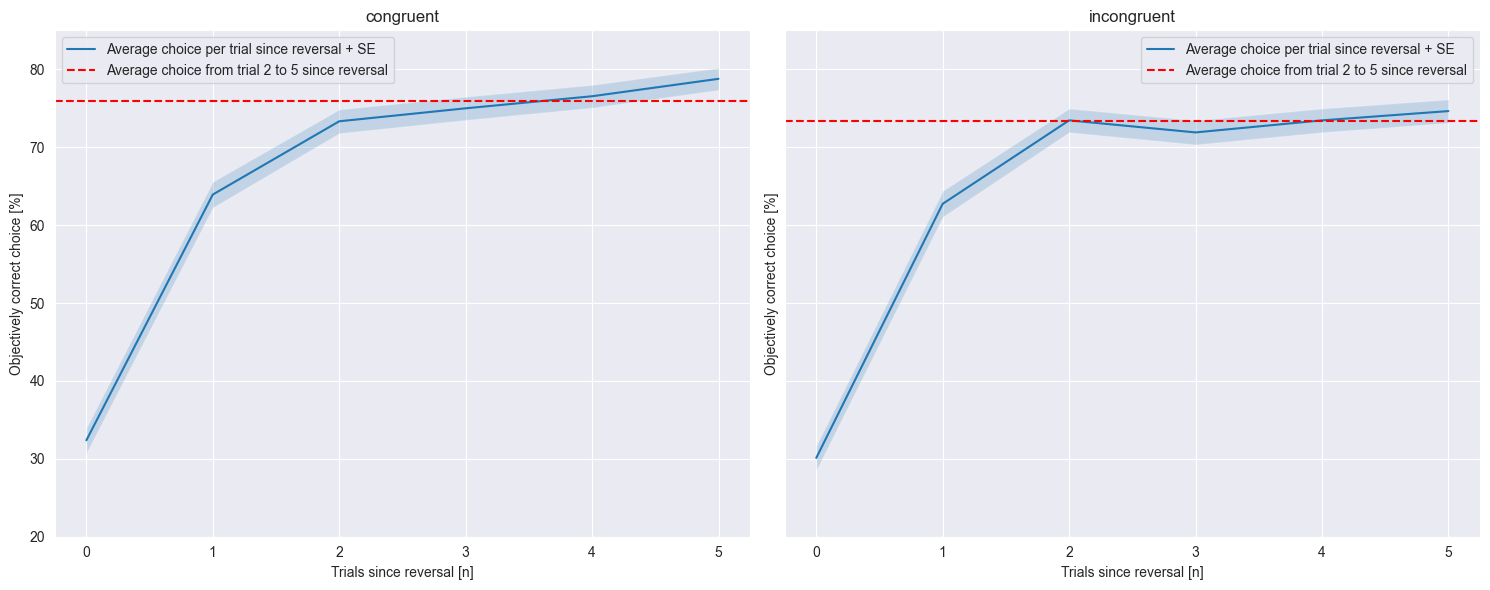

In [40]:
# Prepare the DataFrame by setting 'stimuli_type' as the index temporarily
df = all_reversals_dataframe.set_index('hidden_congruency')

subject_counts = len(df['subject_id'].unique())

# Count the number of times both conditions were shown
group_counts = df.index.value_counts()

# We are not using 'subject_id', so let's exclude it from our calculations
df = df.drop(columns=['subject_id'])
df = df.drop(columns=['stimuli_type'])
df = df.drop(columns=['session'])

# Calculate the mean and standard deviation for each timepoint and stimuli_type
means = df.groupby('hidden_congruency').mean()
means = means*100
means_overall = means.iloc[:, 2:]
average_choice_after_reversal_total = means_overall.mean(axis=1).tolist()
stds = df.groupby('hidden_congruency').sem()
stds = stds * 100

# Plotting
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 6), sharex=False, sharey=True) # Adjust based on the number of stimuli_types
axs = axs.flatten() # Flatten to iterate easily

#fig.suptitle('Objective performance grouped for congruency', fontsize=24, y=0.982)

congruency_list = all_reversals_dataframe['hidden_congruency'].unique()

congruency_types = means.index
for i, congruency_type in enumerate(congruency_types):
    if congruency_type != 'undefined':
        # Timepoints are the column names converted to integers for x-axis values
        timepoints = list(range(plot_range[0], plot_range[1]))
        mean_values = means.loc[congruency_type]
        std_values = stds.loc[congruency_type]

        axs[i].plot(timepoints, mean_values, label='Average choice per trial since reversal + SE')
        axs[i].fill_between(timepoints, mean_values - std_values, mean_values + std_values, alpha=0.2)
        axs[i].axhline((average_choice_after_reversal_total[i]), color='r', linestyle='--', label='Average choice from trial 2 to 5 since reversal')
        #axs[i].plot(probability_dataframe_pivoted[i+1].dropna())
        axs[i].set_title(congruency_type)
        axs[i].set_xlabel('Trials since reversal [n]')
        axs[i].set_ylabel('Objectively correct choice [%]')
        #axs[i].text(-0.2, 72.5, f'{group_counts[congruency_type]} reversals from {subject_counts} subjects', fontsize=10)
        axs[i].legend()
        axs[i].grid(True)

plt.ylim(20, 85)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'objective_performance_grouped_for_hidden_congruency.pdf'))
plt.show()

## Comparing congruency direction

   subject_id     session  congruent  incongruent
0     sub-005  session-02   0.805643     0.812500
1     sub-005  session-03   0.803125     0.814035
2     sub-005  session-04   0.813187     0.758112
3     sub-010  session-02   0.777439     0.756272
4     sub-010  session-03   0.832787     0.800000
5     sub-010  session-04   0.844156     0.845638
6     sub-014  session-02   0.690789     0.656863
7     sub-014  session-03   0.675241     0.703704
8     sub-014  session-04   0.813115     0.791391
9     sub-015  session-02   0.722581     0.785953
10    sub-015  session-03   0.701923     0.777027
11    sub-015  session-04   0.801802     0.803636
12    sub-016  session-02   0.730640     0.796610
13    sub-016  session-03   0.732639     0.786667
14    sub-020  session-02   0.683473     0.864629
15    sub-020  session-03   0.680851     0.794872
16    sub-020  session-04   0.730263     0.688406
17    sub-022  session-02   0.749186     0.808581
18    sub-022  session-03   0.736301     0.772152


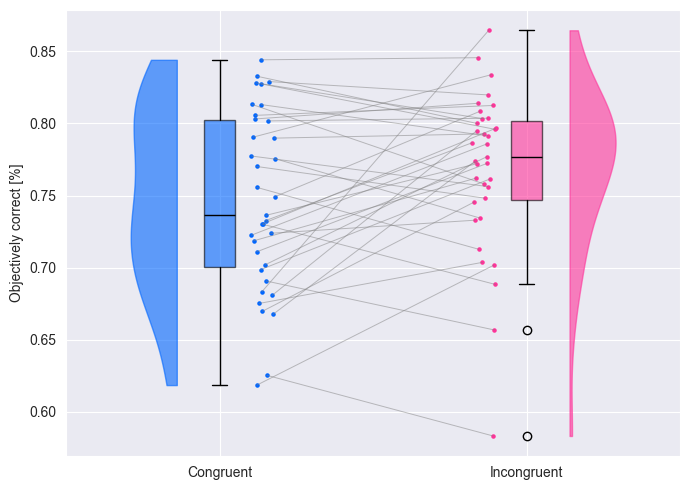

In [41]:
# Comparing overall congruency performance difference
# Single-pass aggregation & reshape
combined_results_pivoted = combined_results_dataframe[combined_results_dataframe['trials_since_reversal'] != 0]
combined_results_pivoted = (
    combined_results_pivoted
    .pivot_table(
        index=['subject_id', 'session'],
        columns='congruency',
        values='objectively_correct_boolean',
        aggfunc='mean'
    )
    .reset_index()
)
combined_results_pivoted = combined_results_pivoted.rename_axis(None, axis=1)
print(combined_results_pivoted)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud_2_groups(
    combined_results_pivoted,
    column_1='congruent',
    column_2='incongruent',
    labels=['Congruent', 'Incongruent'],
    output_dir=output_dir,
    ylabel_name='Objectively correct [%]',
    plot_name='all_trials_objective_performance_congruency'
)

   subject_id     session  congruent  incongruent
0     sub-005  session-02   0.826367     0.790541
1     sub-005  session-03   0.829032     0.786441
2     sub-005  session-04   0.730263     0.834416
3     sub-010  session-02   0.789474     0.742958
4     sub-010  session-03   0.806349     0.827119
5     sub-010  session-04   0.849673     0.840000
6     sub-014  session-02   0.666667     0.681356
7     sub-014  session-03   0.704698     0.674194
8     sub-014  session-04   0.797428     0.807432
9     sub-015  session-02   0.777778     0.732087
10    sub-015  session-03   0.768421     0.712074
11    sub-015  session-04   0.831776     0.770035
12    sub-016  session-02   0.783394     0.746032
13    sub-016  session-03   0.767273     0.753994
14    sub-020  session-02   0.887273     0.636656
15    sub-020  session-03   0.800000     0.673913
16    sub-020  session-04   0.720779     0.698529
17    sub-022  session-02   0.798611     0.760870
18    sub-022  session-03   0.749129     0.760125


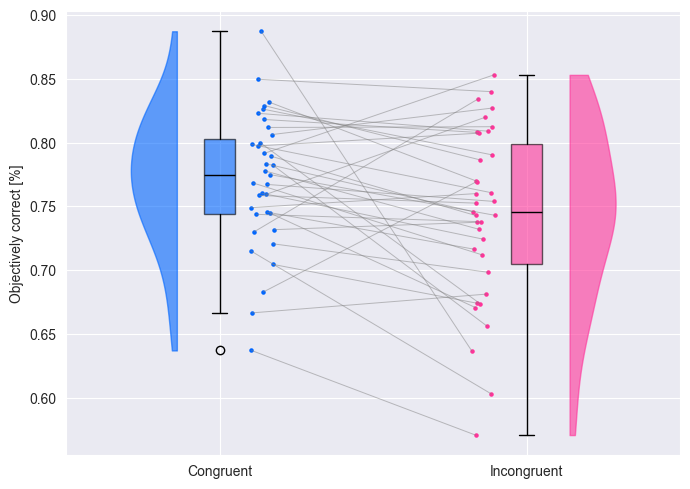

In [42]:
# Comparing overall congruency performance difference
# Single-pass aggregation & reshape
combined_results_pivoted = combined_results_dataframe[combined_results_dataframe['trials_since_reversal'] != 0]
combined_results_pivoted = (
    combined_results_pivoted
    .pivot_table(
        index=['subject_id', 'session'],
        columns='hidden_congruency',
        values='objectively_correct_boolean',
        aggfunc='mean'
    )
    .reset_index()
)
combined_results_pivoted = combined_results_pivoted.rename_axis(None, axis=1)
print(combined_results_pivoted)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud_2_groups(
    combined_results_pivoted,
    column_1='congruent',
    column_2='incongruent',
    labels=['Congruent', 'Incongruent'],
    output_dir=output_dir,
    ylabel_name='Objectively correct [%]',
    plot_name='all_trials_objective_performance_hidden_congruency'
)

In [43]:
'''
# Comparing overall congruency performance difference
# Single-pass aggregation & reshape
combined_results_pivoted = combined_results_dataframe[combined_results_dataframe['trials_since_reversal'] != 0]
combined_results_pivoted = (
    combined_results_pivoted
    .pivot_table(
        index=['subject_id', 'session'],
        columns=['response','valence','volatility'],
        values='objectively_correct_boolean',
        aggfunc='mean'
    )
    .reset_index()
)
combined_results_pivoted = combined_results_pivoted.rename_axis(None, axis=1)
print(combined_results_pivoted)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud_8_groups(
    combined_results_pivoted,
    columns=['response','valence','volatility'],
    output_dir=output_dir,
    ylabel_name='Objectively correct [%]',
    plot_name='all_trials_objective_performance_congruency'
)
'''

"\n# Comparing overall congruency performance difference\n# Single-pass aggregation & reshape\ncombined_results_pivoted = combined_results_dataframe[combined_results_dataframe['trials_since_reversal'] != 0]\ncombined_results_pivoted = (\n    combined_results_pivoted\n    .pivot_table(\n        index=['subject_id', 'session'],\n        columns=['response','valence','volatility'],\n        values='objectively_correct_boolean',\n        aggfunc='mean'\n    )\n    .reset_index()\n)\ncombined_results_pivoted = combined_results_pivoted.rename_axis(None, axis=1)\nprint(combined_results_pivoted)\n\n# Plot the two groups using a raincloud plot\nutils.plotting_functions.paired_raincloud_8_groups(\n    combined_results_pivoted,\n    columns=['response','valence','volatility'],\n    output_dir=output_dir,\n    ylabel_name='Objectively correct [%]',\n    plot_name='all_trials_objective_performance_congruency'\n)\n"

In [44]:
# Create new plots with different intervals that also contain the 50% trials
plot_range = [-6, 6]
static_mapping = {
    0: 'subject_id',
    1: 'stimuli_type',
    2: 'congruency',
}

# pick the first and last values you want in the numeric run
start_value = plot_range[0]
end_value   = plot_range[1]

# build the list of values
values = list(range(start_value, end_value + 1))

# compute where the keys should start (one past your highest static key)
start_key = max(static_mapping) + 1

# zip them together into a dict
numeric_mapping = dict(zip(range(start_key, start_key + len(values)), values))

# merge
mapping = {**static_mapping, **numeric_mapping}

print(mapping)

group_name = 'congruency'
session_name = 'session'
unique_group_types = combined_results_dataframe[group_name].unique()


all_reversals_dataframe = utils.analysis_functions.find_reversals_in_dataframe(combined_results_dataframe,
                                                                             unique_subject_ids, unique_stimuli_types,
                                                                             group_name, plot_range, mapping, session_name)
print(all_reversals_dataframe)

{0: 'subject_id', 1: 'stimuli_type', 2: 'congruency', 3: -6, 4: -5, 5: -4, 6: -3, 7: -2, 8: -1, 9: 0, 10: 1, 11: 2, 12: 3, 13: 4, 14: 5, 15: 6}
      subject_id  trial  stimuli_type  probability_condition  reversal  \
0        sub-005      8             1                     20     False   
1        sub-005     11             1                     20     False   
2        sub-005     12             1                     20     False   
3        sub-005     14             1                     20     False   
4        sub-005     15             1                     20     False   
...          ...    ...           ...                    ...       ...   
22871    sub-037    659             2                     20      True   
22872    sub-037    660             2                     20     False   
22873    sub-037    661             2                     20     False   
22874    sub-037    662             2                     20     False   
22875    sub-037    666             2     

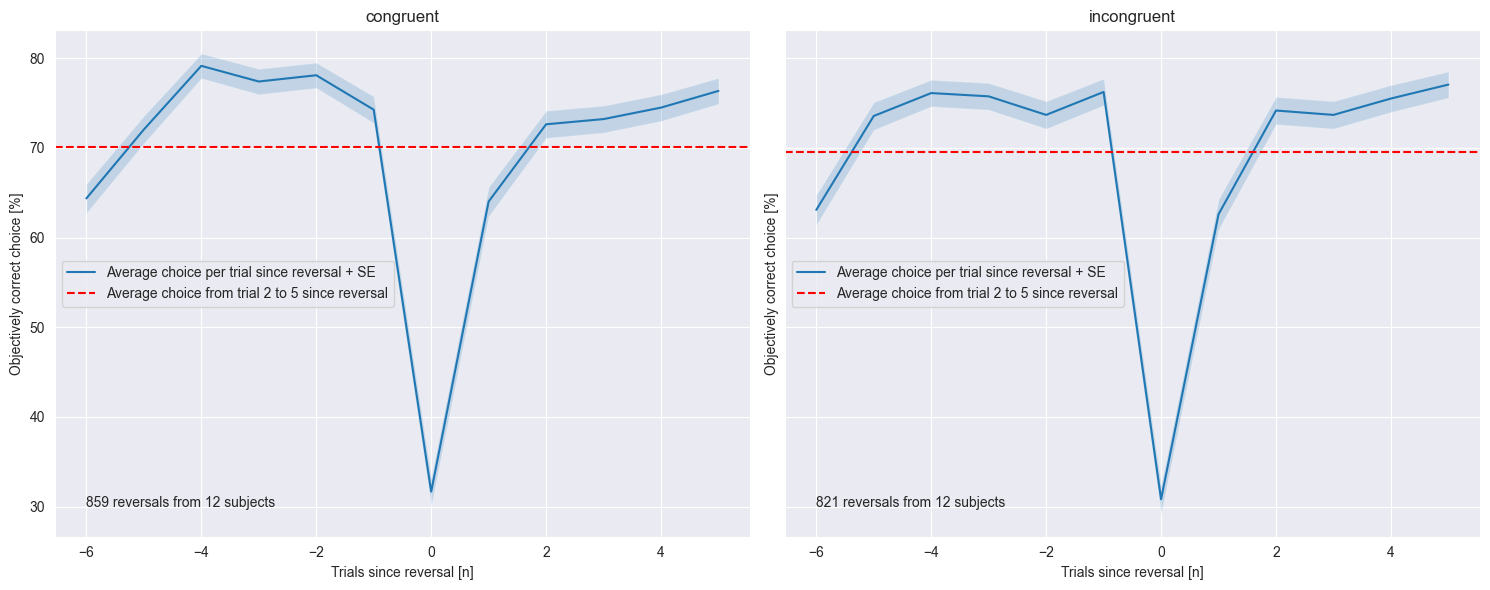

In [45]:
# Prepare the DataFrame by setting 'stimuli_type' as the index temporarily
df = all_reversals_dataframe.set_index('congruency')

subject_counts = len(df['subject_id'].unique())

# Count the number of times both conditions were shown
group_counts = df.index.value_counts()

# We are not using 'subject_id', so let's exclude it from our calculations
df = df.drop(columns=['subject_id'])
df = df.drop(columns=['stimuli_type'])
df = df.drop(columns=['session'])

# Calculate the mean and standard deviation for each timepoint and stimuli_type
means = df.groupby('congruency').mean()
means = means*100
means_overall = means.iloc[:, 2:]
average_choice_after_reversal_total = means_overall.mean(axis=1).tolist()
stds = df.groupby('congruency').sem()
stds = stds * 100

# Plotting
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 6), sharex=False, sharey=True) # Adjust based on the number of stimuli_types
axs = axs.flatten() # Flatten to iterate easily

#fig.suptitle('Objective performance grouped for congruency', fontsize=24, y=0.982)

congruency_list = all_reversals_dataframe['congruency'].unique()

congruency_types = means.index
for i, congruency_type in enumerate(congruency_types):
    if congruency_type != 'undefined':
        # Timepoints are the column names converted to integers for x-axis values
        timepoints = list(range(plot_range[0], plot_range[1]))
        mean_values = means.loc[congruency_type]
        std_values = stds.loc[congruency_type]

        axs[i].plot(timepoints, mean_values, label='Average choice per trial since reversal + SE')
        axs[i].fill_between(timepoints, mean_values - std_values, mean_values + std_values, alpha=0.2)
        axs[i].axhline((average_choice_after_reversal_total[i]), color='r', linestyle='--', label='Average choice from trial 2 to 5 since reversal')
        #axs[i].plot(probability_dataframe_pivoted[i+1].dropna())
        axs[i].set_title(congruency_type)
        axs[i].set_xlabel('Trials since reversal [n]')
        axs[i].set_ylabel('Objectively correct choice [%]')
        axs[i].text(-6, 30, f'{group_counts[congruency_type]} reversals from {subject_counts} subjects', fontsize=10)
        axs[i].legend()
        axs[i].grid(True)

#plt.ylim(20, 85)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'objective_performance_grouped_for_congruency_before_and_after.pdf'))
plt.show()
plot_range = [0, 6]

# Chance of a forward response around reversal
Here, we plot the chance of a forward response around a reversal, hoping to capture a flip in the reversal for the four categories:
- happy incongruent > congruent
- angry incongruent > congruent
- happy congruent > incongruent
- angry congruent > incongruent

In [46]:
# First create a new dataframe with the 
adjusted_plot_range = [plot_range[0] - plot_range[1], plot_range[1] - 1]
dataframe = utils.analysis_functions.bin_responses_for_congruency(combined_results_dataframe, adjusted_plot_range, 'stimuli_type')

# Map transitions to congruency
to_flip = {
    'happy_congruent_to_incongruent',
    'happy_incongruent_to_congruent'
}

# build a boolean mask for rows to flip
mask = dataframe['emotional_valence_and_transition'].isin(to_flip)

# apply the flip
dataframe.loc[mask, 'response_int'] = 100 - dataframe.loc[mask, 'response_int']

# define your mapping
mapping = {
    'angry_congruent_to_incongruent':    'congruent_to_incongruent',
    'happy_incongruent_to_congruent':    'incongruent_to_congruent',
    'angry_incongruent_to_congruent':    'incongruent_to_congruent',
    'happy_congruent_to_incongruent':    'congruent_to_incongruent',
    'angry_no_transition':               'no_transition',
    'happy_no_transition':               'no_transition',
}

# create new column
dataframe['transitions_combined'] = (
    dataframe['emotional_valence_and_transition']
     .map(mapping)
     .fillna('unknown')   # optional: catch any unexpected values
)

print(dataframe[['trials_around_reversal','stimuli_type','congruency']])

[0, 30, 62, 68, 76, 82, 90, 96, 106, 138, 166, 174, 183, 189, 195, 205, 213, 242, 270, 276, 286, 293, 303, 311, 321, 327, 357, 389, 395, 403, 409, 417, 423, 433, 465, 493, 501, 511, 517, 523, 532, 540, 570, 598, 604, 614, 622, 632, 640, 650, 686, 716, 722, 732, 742, 749, 759, 765, 797, 829, 837, 847, 853, 861, 871, 879, 907, 935, 945, 951, 957, 965, 973, 979, 985, 1014, 1044, 1050, 1060, 1070, 1078, 1088, 1094, 1125, 1157, 1164, 1174, 1180, 1188, 1198, 1206, 1233, 1261, 1271, 1277, 1283, 1291, 1299, 1305, 1311, 1321, 1331, 1339, 1347, 1355, 1361, 1389, 1419, 1429, 1439, 1449, 1457, 1463, 1471, 1501, 1533, 1539, 1545, 1553, 1563, 1569, 1575, 1603, 1635, 1641, 1651, 1661, 1669, 1677, 1685, 1691, 1719, 1749, 1759, 1769, 1779, 1787, 1793, 1801, 1831, 1863, 1869, 1875, 1883, 1893, 1899, 1905, 1933, 1965, 1971, 1981, 1987, 1997, 2003, 2011, 2021, 2053, 2083, 2091, 2099, 2105, 2115, 2122, 2130, 2160, 2188, 2196, 2202, 2212, 2222, 2228, 2234, 2266, 2294, 2300, 2310, 2315, 2325, 2331, 2339, 234

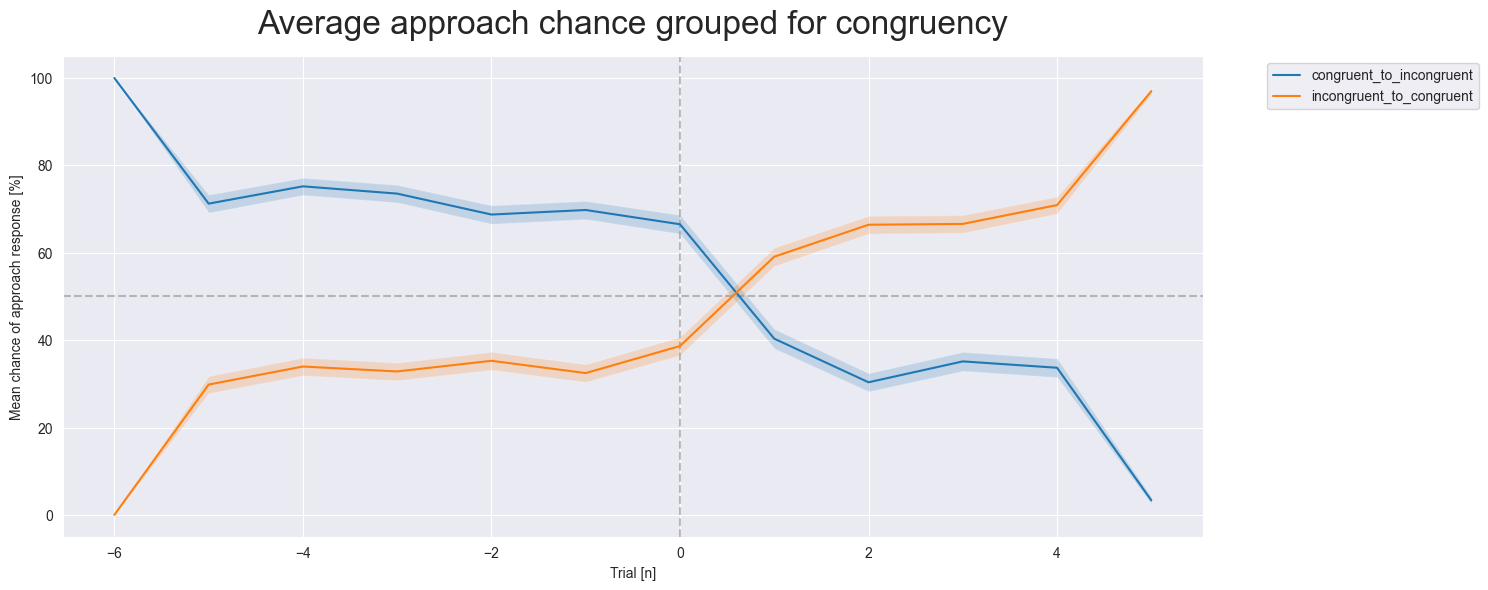

In [47]:
# Group the data
grouped_dataframe = dataframe.groupby(['trials_around_reversal', 'transitions_combined'])['response_int'].agg(['mean', 'sem']).reset_index()

# Plotting with Matplotlib
plt.figure(figsize=(15, 6))

# Define the unique groups for 'emotional_valence' and 'transition'
transitions = grouped_dataframe['transitions_combined'].unique()
transitions = [s for s in transitions if 'no_transition' not in s]

# Plot each group
plt.axhline(50, color='grey', linestyle='dashed', alpha=0.5)
plt.axvline(0, color='grey', linestyle='dashed', alpha=0.5)
for transition in transitions:
    subset = grouped_dataframe[grouped_dataframe['transitions_combined'] == transition]
    current_transition = subset['transitions_combined'].unique()
    if not subset.empty:
        plt.plot(subset['trials_around_reversal'], subset['mean'], label=f'{transition}')
        plt.fill_between(subset['trials_around_reversal'], subset['mean'] - subset['sem'], subset['mean'] + subset['sem'], alpha=0.2)

# Customize the plot
plt.xlabel('Trial [n]')
plt.ylabel('Mean chance of approach response [%]')
plt.title('Average approach chance grouped for congruency', fontsize=24, y=1.03)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()

plt.savefig(os.path.join(output_dir, 'average_approach_chance_grouped_for_congruency.pdf'))
# Show the plot
plt.show()

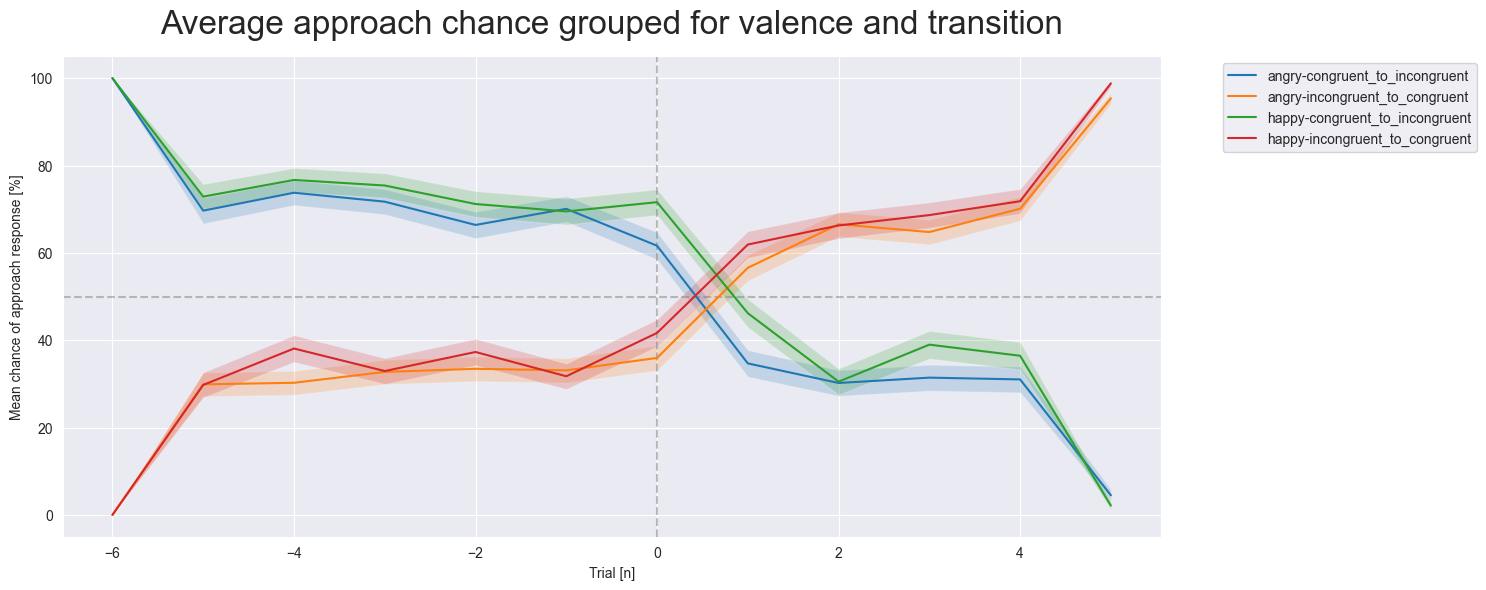

In [48]:
# Group the data
grouped_dataframe = dataframe.groupby(['trials_around_reversal', 'emotional_valence', 'transition'])['response_int'].agg(['mean', 'sem']).reset_index()

# Plotting with Matplotlib
plt.figure(figsize=(15, 6))

# Define the unique groups for 'emotional_valence' and 'transition'
emotional_valences = grouped_dataframe['emotional_valence'].unique()
transitions = grouped_dataframe['transition'].unique()
transitions = transitions[transitions != 'no_transition']

# Plot each group
plt.axhline(50, color='grey', linestyle='dashed', alpha=0.5)
plt.axvline(0, color='grey', linestyle='dashed', alpha=0.5)
for valence in emotional_valences:
    for transition in transitions:
        subset = grouped_dataframe[(grouped_dataframe['emotional_valence'] == valence) & (grouped_dataframe['transition'] == transition)]
        current_emotion = subset['emotional_valence'].unique()
        current_transition = subset['transition'].unique()
        if not subset.empty:
            plt.plot(subset['trials_around_reversal'], subset['mean'], label=f'{valence}-{transition}')
            plt.fill_between(subset['trials_around_reversal'], subset['mean'] - subset['sem'], subset['mean'] + subset['sem'], alpha=0.2)

# Customize the plot
plt.xlabel('Trial [n]')
plt.ylabel('Mean chance of approach response [%]')
plt.title('Average approach chance grouped for valence and transition', fontsize=24, y=1.03)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()

plt.savefig(os.path.join(output_dir, 'average_approach_chance_grouped_for_valence_and_transition.pdf'))
# Show the plot
plt.show()

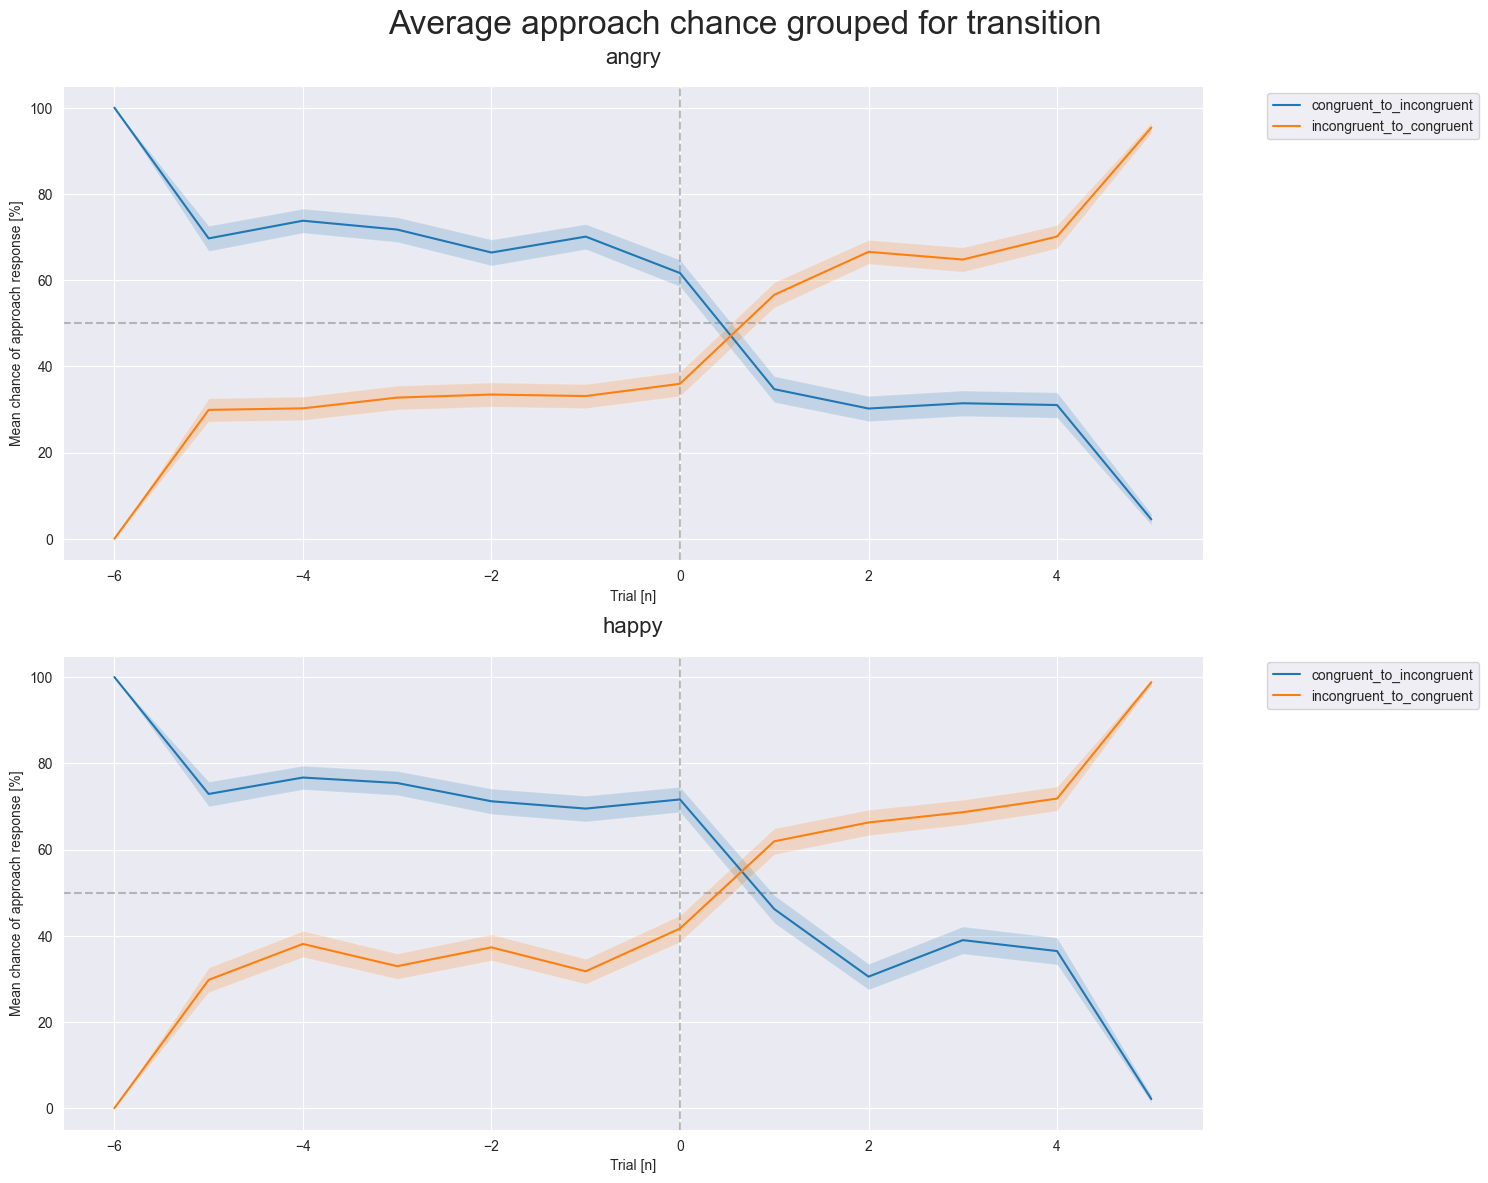

In [49]:
# Plotting with Matplotlib
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(15, 12), sharey=True)

fig.suptitle('Average approach chance grouped for transition', fontsize=24, y=0.982)

# Plot each group
for valence_index, valence_value in enumerate(emotional_valences):
    axes[valence_index].axhline(50, color='grey', linestyle='dashed', alpha=0.5)
    axes[valence_index].axvline(0, color='grey', linestyle='dashed', alpha=0.5)
    for transition in transitions:
        subset = grouped_dataframe[(grouped_dataframe['emotional_valence'] == valence_value) & (grouped_dataframe['transition'] == transition)]
        current_emotion = subset['emotional_valence'].unique()
        current_transition = subset['transition'].unique()
        if not subset.empty:
            axes[valence_index].plot(subset['trials_around_reversal'], subset['mean'], label=f'{transition}')
            axes[valence_index].fill_between(subset['trials_around_reversal'], subset['mean'] - subset['sem'], subset['mean'] + subset['sem'], alpha=0.2)

    # Customize the plot
    axes[valence_index].set_xlabel('Trial [n]')
    axes[valence_index].set_ylabel('Mean chance of approach response [%]')
    axes[valence_index].set_title(valence_value, fontsize=16, y=1.03)
    axes[valence_index].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.grid(True)
plt.tight_layout()

plt.savefig(os.path.join(output_dir, 'average_approach_chance_separated_by_valence_and_grouped_for_transition.pdf'))
# Show the plot
plt.show()

In [50]:
# Add a plot where the two emotions are combined and one transition is inverted to compare them bettter

# Plot volatile and stable blocks separately
Fix this, clearly broken

In [51]:
'''pd.set_option('display.max_rows', None)
# Check if a block is volatile or stable
dataframe = combined_results_dataframe[combined_results_dataframe['probability_condition'] != 50]
dataframe = utils.analysis_functions.check_volatility(dataframe)
dataframe = dataframe.sort_values(by=['subject_id', 'session', 'stimuli_type', 'trial'], ascending=[True, True, True, True])
print(dataframe[['subject_id', 'session', 'trial', 'stimuli_type', 'probability_condition', 'volatility']])'''
dataframe = combined_results_dataframe
print(combined_results_dataframe)

       trial  emotional_cue_time response objectively_correct  \
0          8        1.741947e+09       up               False   
0          9        1.741947e+09       up                True   
1         10        1.741947e+09     down               False   
1         11        1.741947e+09       up               False   
2         12        1.741947e+09       up               False   
...      ...                 ...      ...                 ...   
11546    663        1.754051e+09     down               False   
11547    664        1.754051e+09     down               False   
11548    665        1.754051e+09       up                True   
11549    666        1.754051e+09     down                True   
11549    667        1.754051e+09       up                True   

      subjectively_correct  response_time   RT_s  feedback_time  stimuli_type  \
0                    False   1.741947e+09  0.635   1.741947e+09             1   
0                    False   1.741947e+09  0.832   1.7419

In [52]:
# Create new plots with different intervals that also contain the 50% trials
mapping = {0: 'subject_id', 1: 'stimuli_type', 2: 'volatility', 3: 0, 4: 1, 5: 2, 6: 3, 7: 4, 8: 5}
group_name = 'volatility'
session_name = 'session'
unique_group_types = combined_results_dataframe[group_name].unique()
pd.set_option('display.max_rows', 20)
dataframe_with_session = utils.analysis_functions.find_reversals_in_dataframe(combined_results_dataframe,
                                                                unique_subject_ids, unique_stimuli_types,
                                                                group_name, plot_range, mapping, session_name)

print(dataframe_with_session)

dataframe_without_session = utils.analysis_functions.find_reversals_in_dataframe(combined_results_dataframe,
                                                                unique_subject_ids, unique_stimuli_types,
                                                                group_name, plot_range, mapping)

print(dataframe_without_session)

      subject_id  trial  stimuli_type  probability_condition  reversal  \
0        sub-005      8             1                     20     False   
1        sub-005     11             1                     20     False   
2        sub-005     12             1                     20     False   
3        sub-005     14             1                     20     False   
4        sub-005     15             1                     20     False   
...          ...    ...           ...                    ...       ...   
22871    sub-037    659             2                     20      True   
22872    sub-037    660             2                     20     False   
22873    sub-037    661             2                     20     False   
22874    sub-037    662             2                     20     False   
22875    sub-037    666             2                     20     False   

      volatility     session  
0       volatile  session-02  
1       volatile  session-02  
2       volatile  

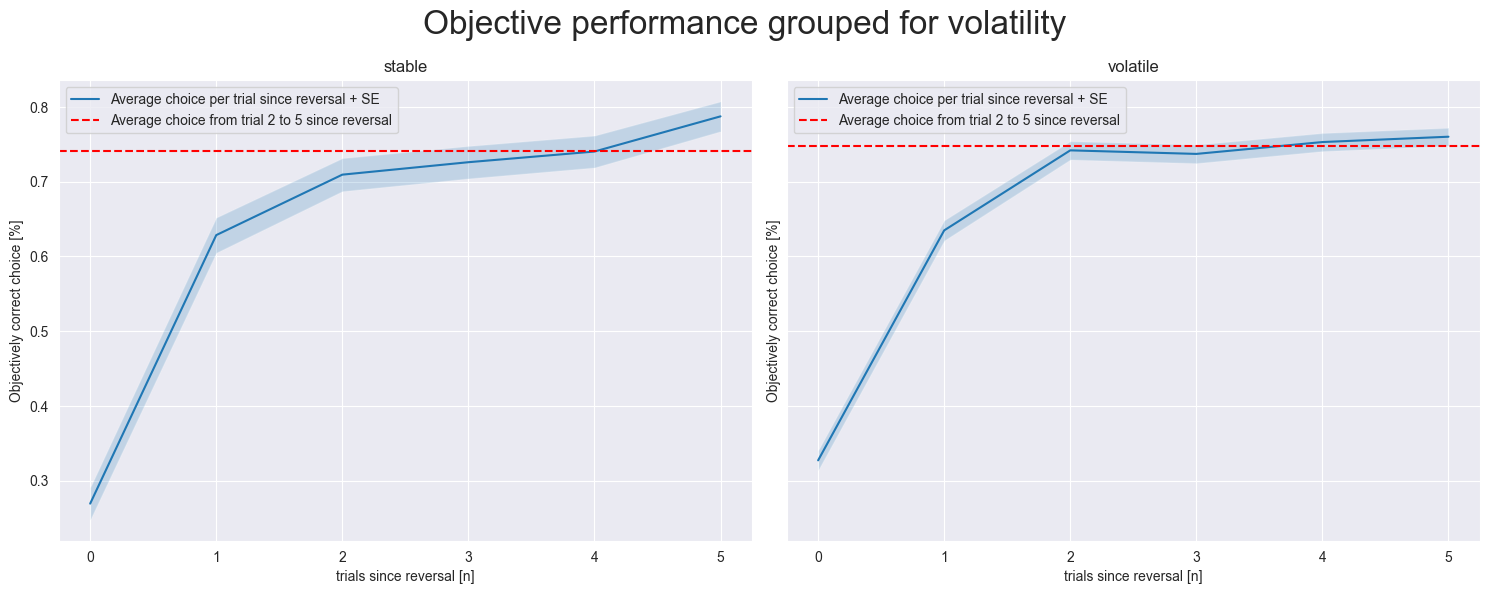

In [53]:
# Prepare the DataFrame by setting 'stimuli_type' as the index temporarily
df = dataframe_without_session.set_index('volatility')

subject_counts = len(df['subject_id'].unique())

# Count the number of times both conditions were shown
group_counts = df.index.value_counts()

# We are not using 'subject_id', so let's exclude it from our calculations
df = df.drop(columns=['subject_id'])
df = df.drop(columns=['stimuli_type'])

# Calculate the mean and standard deviation for each timepoint and stimuli_type
means = df.groupby('volatility').mean()
means_overall = means.iloc[:, 2:]
average_choice_after_reversal_total = means_overall.mean(axis=1).tolist()
stds = df.groupby('volatility').sem()

# Plotting
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 6), sharex=False, sharey=True) # Adjust based on the number of stimuli_types
axs = axs.flatten() # Flatten to iterate easily

fig.suptitle('Objective performance grouped for volatility', fontsize=24, y=0.982)

congruency_list = dataframe_without_session['volatility'].unique()

congruency_types = means.index
for i, congruency_type in enumerate(congruency_types):
    # Timepoints are the column names converted to integers for x-axis values
    timepoints = list(range(plot_range[0], plot_range[1]))
    mean_values = means.loc[congruency_type]
    std_values = stds.loc[congruency_type]

    axs[i].plot(timepoints, mean_values, label='Average choice per trial since reversal + SE')
    axs[i].fill_between(timepoints, mean_values - std_values, mean_values + std_values, alpha=0.2)
    axs[i].axhline((average_choice_after_reversal_total[i]), color='r', linestyle='--', label='Average choice from trial 2 to 5 since reversal')
    #axs[i].plot(probability_dataframe_pivoted[i+1].dropna())
    axs[i].set_title(congruency_type)
    axs[i].set_xlabel('trials since reversal [n]')
    axs[i].set_ylabel('Objectively correct choice [%]')
    #axs[i].text(0, 0.75, f'{group_counts[congruency_type]} reversals from {subject_counts} subjects', fontsize=10)
    axs[i].legend()
    axs[i].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'objective_performance_grouped_for_volatility.pdf'))
plt.show()

   subject_id     session    stable  volatile
0     sub-005  session-02  0.843658  0.665615
1     sub-005  session-03  0.779710  0.741935
2     sub-005  session-04  0.787791  0.693038
3     sub-010  session-02  0.733918  0.747604
4     sub-010  session-03  0.793510  0.771160
..        ...         ...       ...       ...
30    sub-029  session-03  0.697143  0.673203
31    sub-029  session-04  0.755102  0.695238
32    sub-037  session-02  0.771261  0.675241
33    sub-037  session-03  0.728324  0.702614
34    sub-037  session-04  0.735294  0.661342

[35 rows x 4 columns]


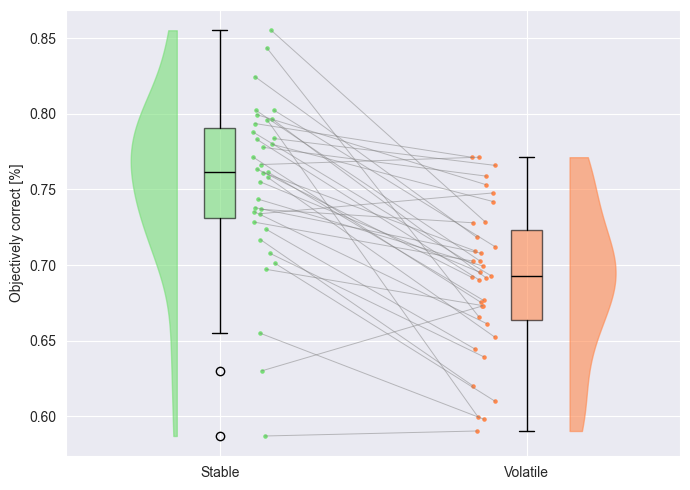

In [55]:
# Comparing overall congruency performance difference
# Single-pass aggregation & reshape
combined_results_pivoted = (
    combined_results_dataframe
    .pivot_table(
        index=['subject_id', 'session'],
        columns='volatility',
        values='objectively_correct_boolean',
        aggfunc='mean'
    )
    .reset_index()
)
combined_results_pivoted = combined_results_pivoted.rename_axis(None, axis=1)
print(combined_results_pivoted)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud_2_groups(
    combined_results_pivoted,
    column_1='stable',
    column_2='volatile',
    labels=['Stable', 'Volatile'],
    output_dir=output_dir,
    ylabel_name='Objectively correct [%]',
    plot_name='all_trials_objective_performance_volatility',
    colours=['#77DF77', '#FF884D']
)

   subject_id     session  congruent_stable  congruent_volatile  \
0     sub-005  session-02          0.832432            0.668790   
1     sub-005  session-03          0.779874            0.743316   
2     sub-005  session-04          0.802920            0.735849   
3     sub-010  session-02          0.728814            0.779070   
4     sub-010  session-03          0.768750            0.831325   
..        ...         ...               ...                 ...   
30    sub-029  session-03          0.677083            0.602339   
31    sub-029  session-04          0.748503            0.729282   
32    sub-037  session-02          0.790419            0.606452   
33    sub-037  session-03          0.715847            0.644295   
34    sub-037  session-04          0.717647            0.729560   

    incongruent_stable  incongruent_volatile  
0             0.857143              0.662500  
1             0.779570              0.739837  
2             0.777778              0.649682  
3      

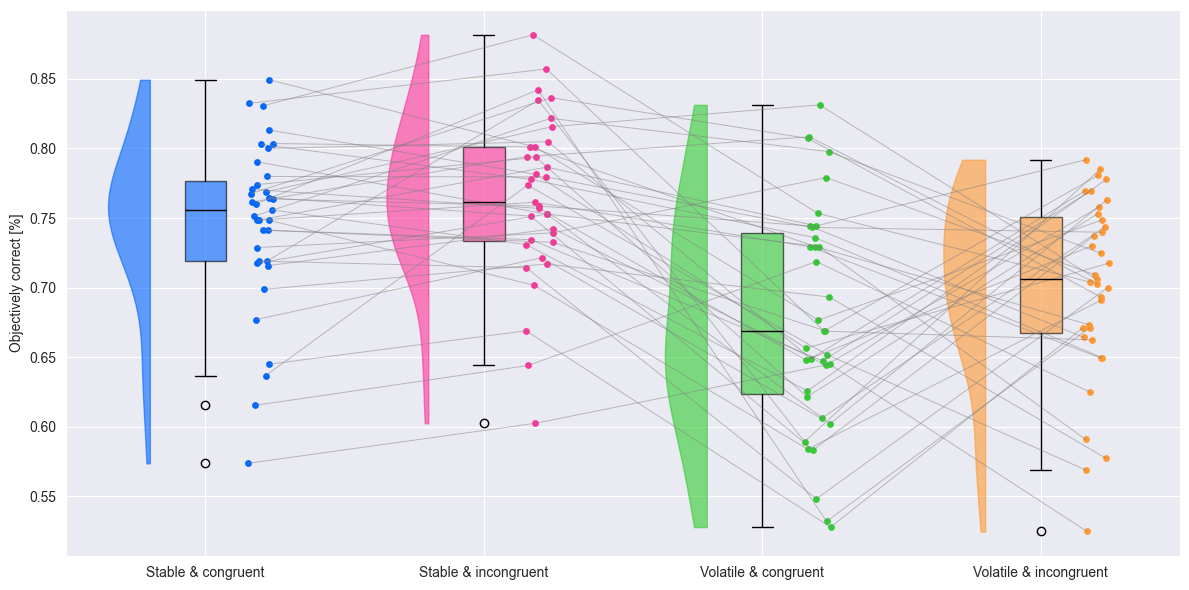

In [56]:
# Comparing overall congruency and volatility performance interaction
# Single-pass aggregation & reshape
combined_results_pivoted = (
    combined_results_dataframe
    .pivot_table(
        index=['subject_id', 'session'],
        columns=['congruency','volatility'],
        values='objectively_correct_boolean',
        aggfunc='mean'
    )
    .reset_index()
)
combined_results_pivoted.columns = [
    f"{a}_{b}" if b else a
    for a, b in combined_results_pivoted.columns
]
print(combined_results_pivoted)

# Plot the four groups using a raincloud plot
utils.plotting_functions.paired_raincloud_4_groups(
    combined_results_pivoted,
    columns=['congruent_stable','incongruent_stable','congruent_volatile','incongruent_volatile'],
    labels=['Stable & congruent','Stable & incongruent','Volatile & congruent','Volatile & incongruent'],
    output_dir=output_dir,
    ylabel_name='Objectively correct [%]',
    plot_name='all_trials_objective_performance_congruency_volatility'
)

   subject_id     session  congruent_stable  congruent_volatile  \
0     sub-005  session-02          0.875000            0.660377   
1     sub-005  session-03          0.751515            0.812865   
2     sub-005  session-04          0.705128            0.680233   
3     sub-010  session-02          0.750000            0.765714   
4     sub-010  session-03          0.788462            0.754098   
..        ...         ...               ...                 ...   
30    sub-029  session-03          0.747126            0.762963   
31    sub-029  session-04          0.748503            0.737430   
32    sub-037  session-02          0.754286            0.701493   
33    sub-037  session-03          0.757225            0.716418   
34    sub-037  session-04          0.743902            0.648045   

    incongruent_stable  incongruent_volatile  
0             0.809816              0.670886  
1             0.805556              0.654676  
2             0.856383              0.708333  
3      

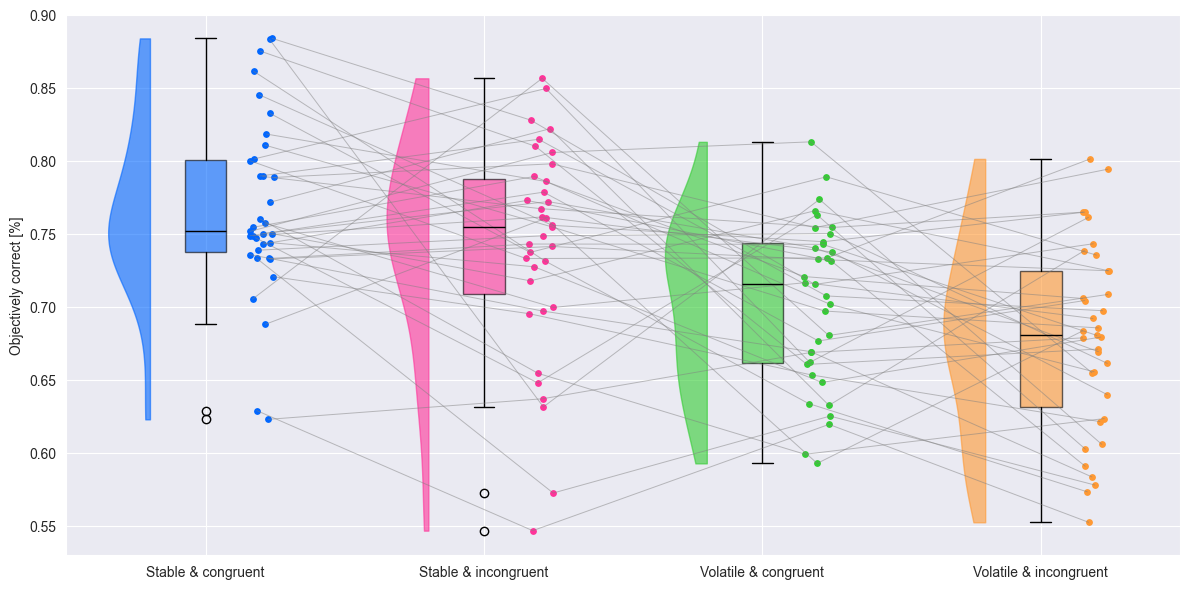

In [57]:
# Comparing overall congruency and volatility performance interaction
# Single-pass aggregation & reshape
combined_results_pivoted = (
    combined_results_dataframe
    .pivot_table(
        index=['subject_id', 'session'],
        columns=['hidden_congruency','volatility'],
        values='objectively_correct_boolean',
        aggfunc='mean'
    )
    .reset_index()
)
combined_results_pivoted.columns = [
    f"{a}_{b}" if b else a
    for a, b in combined_results_pivoted.columns
]
print(combined_results_pivoted)

# Plot the four groups using a raincloud plot
utils.plotting_functions.paired_raincloud_4_groups(
    combined_results_pivoted,
    columns=['congruent_stable','incongruent_stable','congruent_volatile','incongruent_volatile'],
    labels=['Stable & congruent','Stable & incongruent','Volatile & congruent','Volatile & incongruent'],
    output_dir=output_dir,
    ylabel_name='Objectively correct [%]',
    plot_name='all_trials_objective_performance_hidden_congruency_volatility'
)

   subject_id     session  angry_-1   angry_1  happy_-1   happy_1
0     sub-005  session-02  0.279503  0.265060  0.221591  0.202614
1     sub-005  session-03  0.239521  0.197531  0.277174  0.232394
2     sub-005  session-04  0.305263  0.242857  0.224359  0.247126
3     sub-010  session-02  0.270833  0.275676  0.213415  0.277778
4     sub-010  session-03  0.236364  0.202454  0.196319  0.233533
..        ...         ...       ...       ...       ...       ...
30    sub-029  session-03  0.285714  0.365714  0.351064  0.230216
31    sub-029  session-04  0.323529  0.256250  0.265957  0.242857
32    sub-037  session-02  0.251534  0.300613  0.295597  0.251497
33    sub-037  session-03  0.244048  0.286624  0.342857  0.256579
34    sub-037  session-04  0.300000  0.255952  0.298137  0.347561

[35 rows x 6 columns]
plotting is turned off


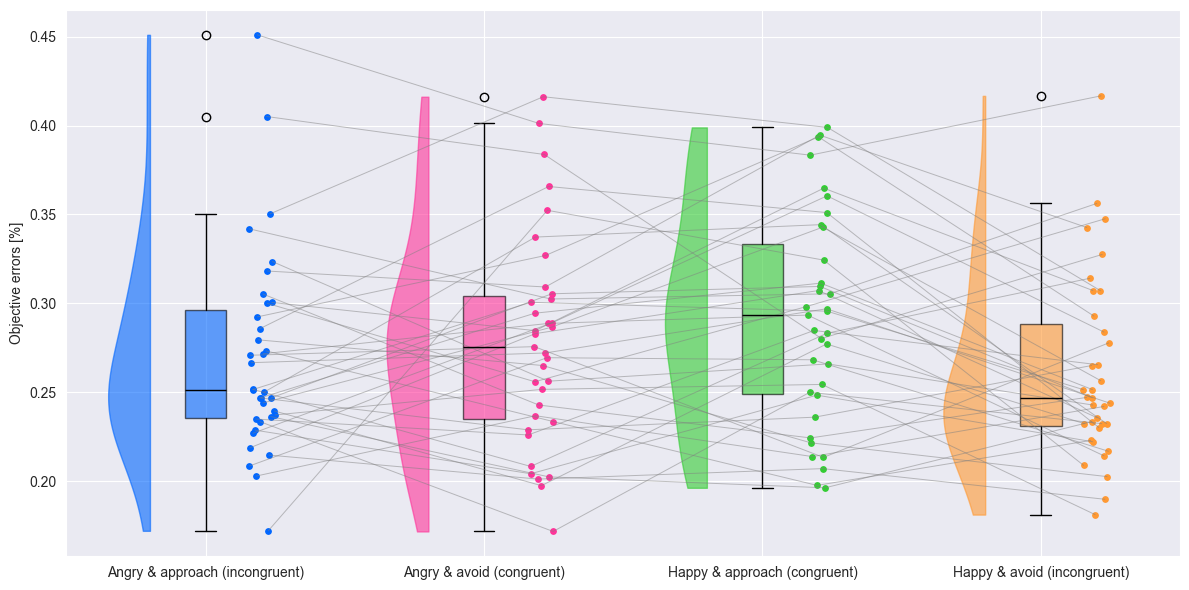

In [58]:
# Comparing overall congruency and volatility performance interaction
# Single-pass aggregation & reshape
combined_results_pivoted = (
    combined_results_dataframe
    .pivot_table(
        index=['subject_id', 'session'],
        columns=['valence','response_boolean'],
        values='objective_errors',
        aggfunc='mean'
    )
    .reset_index()
)
combined_results_pivoted.columns = [
    f"{a}_{b}" if b else a
    for a, b in combined_results_pivoted.columns
]
print(combined_results_pivoted)

# Plot the four groups using a raincloud plot
utils.plotting_functions.paired_raincloud_4_groups(
    combined_results_pivoted,
    columns=['angry_-1','angry_1','happy_-1','happy_1'],
    labels=['Angry & approach (incongruent)','Angry & avoid (congruent)','Happy & approach (congruent)','Happy & avoid (incongruent)'],
    output_dir=output_dir,
    ylabel_name='Objective errors [%]',
    plot_name='all_trials_objective_errors_responses',
    plot_title='Errors given response'
)

   subject_id     session  angry_-1   angry_1  happy_-1   happy_1
0     sub-005  session-02  0.395062  0.389610  0.275000  0.278481
1     sub-005  session-03  0.257143  0.200000  0.303922  0.264151
2     sub-005  session-04  0.402299  0.281690  0.250000  0.285714
3     sub-010  session-02  0.253731  0.222222  0.219512  0.324324
4     sub-010  session-03  0.293333  0.178571  0.158537  0.294872
..        ...         ...       ...       ...       ...       ...
30    sub-029  session-03  0.239437  0.385542  0.409091  0.234375
31    sub-029  session-04  0.384615  0.250000  0.287129  0.303571
32    sub-037  session-02  0.243590  0.384615  0.402597  0.269231
33    sub-037  session-03  0.231707  0.328571  0.379747  0.253333
34    sub-037  session-04  0.405405  0.277108  0.263158  0.412500

[35 rows x 6 columns]
plotting is turned off


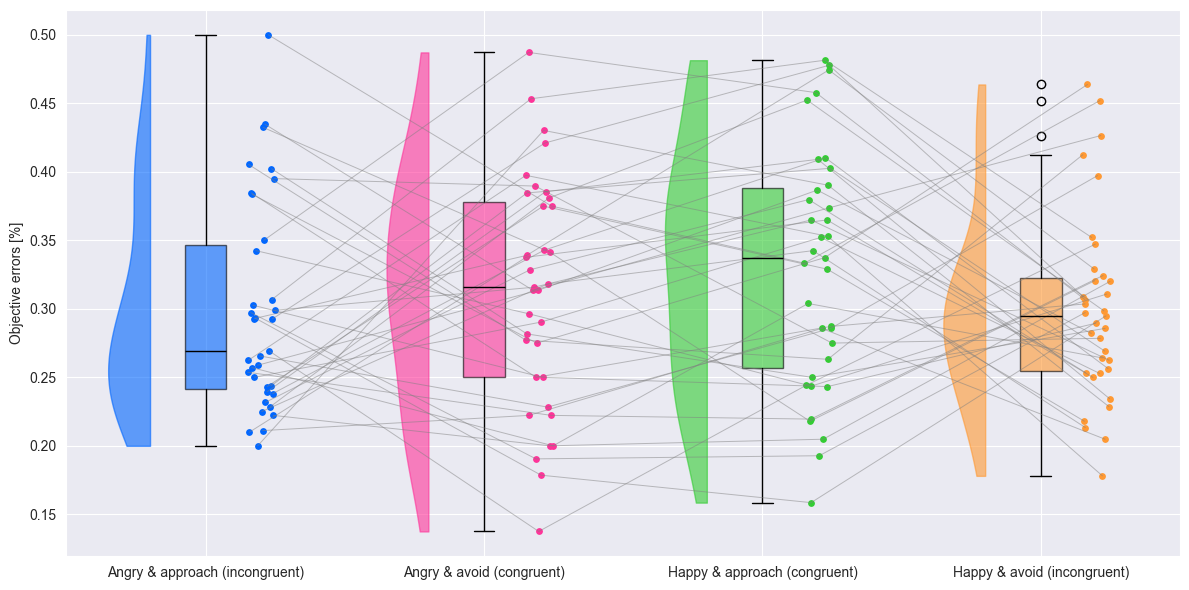

In [59]:
# Comparing overall congruency and volatility performance interaction
# Single-pass aggregation & reshape
combined_results_pivoted = combined_results_dataframe[combined_results_dataframe['volatility'] == 'volatile']
combined_results_pivoted = (
    combined_results_pivoted
    .pivot_table(
        index=['subject_id', 'session'],
        columns=['valence','response_boolean'],
        values='objective_errors',
        aggfunc='mean'
    )
    .reset_index()
)
combined_results_pivoted.columns = [
    f"{a}_{b}" if b else a
    for a, b in combined_results_pivoted.columns
]
print(combined_results_pivoted)

# Plot the four groups using a raincloud plot
utils.plotting_functions.paired_raincloud_4_groups(
    combined_results_pivoted,
    columns=['angry_-1','angry_1','happy_-1','happy_1'],
    labels=['Angry & approach (incongruent)','Angry & avoid (congruent)','Happy & approach (congruent)','Happy & avoid (incongruent)'],
    output_dir=output_dir,
    ylabel_name='Objective errors [%]',
    plot_name='all_trials_objective_errors_volatile_responses',
    plot_title='Errors given response volatile'
)

   subject_id     session  angry_-1   angry_1  happy_-1   happy_1
0     sub-005  session-02  0.162500  0.157303  0.177083  0.121622
1     sub-005  session-03  0.226804  0.194805  0.243902  0.213483
2     sub-005  session-04  0.223301  0.202899  0.191176  0.221154
3     sub-010  session-02  0.285714  0.326316  0.207317  0.238636
4     sub-010  session-03  0.188889  0.227848  0.234568  0.179775
..        ...         ...       ...       ...       ...       ...
30    sub-029  session-03  0.325301  0.347826  0.300000  0.226667
31    sub-029  session-04  0.271739  0.262500  0.241379  0.202381
32    sub-037  session-02  0.258824  0.223529  0.195122  0.235955
33    sub-037  session-03  0.255814  0.252874  0.312500  0.259740
34    sub-037  session-04  0.209302  0.235294  0.329412  0.285714

[35 rows x 6 columns]
plotting is turned off


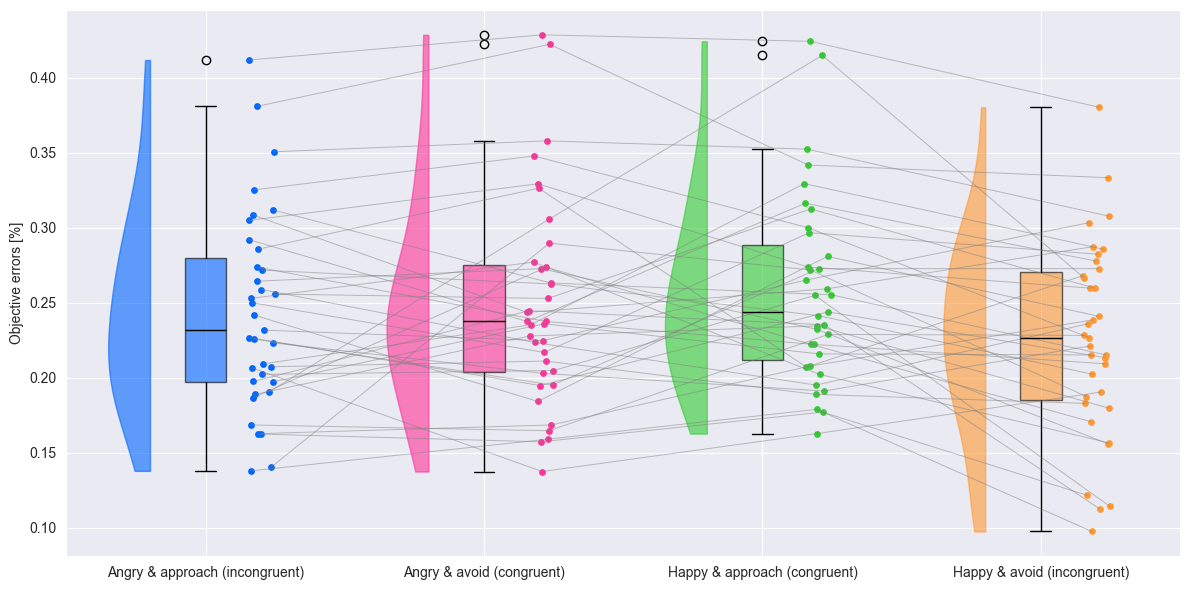

In [60]:
# Comparing overall congruency and volatility performance interaction
# Single-pass aggregation & reshape
combined_results_pivoted = combined_results_dataframe[combined_results_dataframe['volatility'] == 'stable']
combined_results_pivoted = (
    combined_results_pivoted
    .pivot_table(
        index=['subject_id', 'session'],
        columns=['valence','response_boolean'],
        values='objective_errors',
        aggfunc='mean'
    )
    .reset_index()
)
combined_results_pivoted.columns = [
    f"{a}_{b}" if b else a
    for a, b in combined_results_pivoted.columns
]
print(combined_results_pivoted)

# Plot the four groups using a raincloud plot
utils.plotting_functions.paired_raincloud_4_groups(
    combined_results_pivoted,
    columns=['angry_-1','angry_1','happy_-1','happy_1'],
    labels=['Angry & approach (incongruent)','Angry & avoid (congruent)','Happy & approach (congruent)','Happy & avoid (incongruent)'],
    output_dir=output_dir,
    ylabel_name='Objective errors [%]',
    plot_name='all_trials_objective_errors_stable_responses',
    plot_title='Errors given response stable'
)

   subject_id     session  angry_-1   angry_1  happy_-1   happy_1
0     sub-005  session-02  0.379747  0.405063  0.275000  0.278481
1     sub-005  session-03  0.246377  0.209302  0.164706  0.442857
2     sub-005  session-04  0.277778  0.406977  0.232558  0.305556
3     sub-010  session-02  0.285714  0.195402  0.272727  0.264706
4     sub-010  session-03  0.220588  0.241758  0.250000  0.191176
..        ...         ...       ...       ...       ...       ...
30    sub-029  session-03  0.372093  0.250000  0.223881  0.423529
31    sub-029  session-04  0.294118  0.333333  0.191011  0.426471
32    sub-037  session-02  0.337079  0.283582  0.313433  0.352273
33    sub-037  session-03  0.267442  0.287879  0.279412  0.348837
34    sub-037  session-04  0.343284  0.333333  0.370787  0.298507

[35 rows x 6 columns]
plotting is turned off


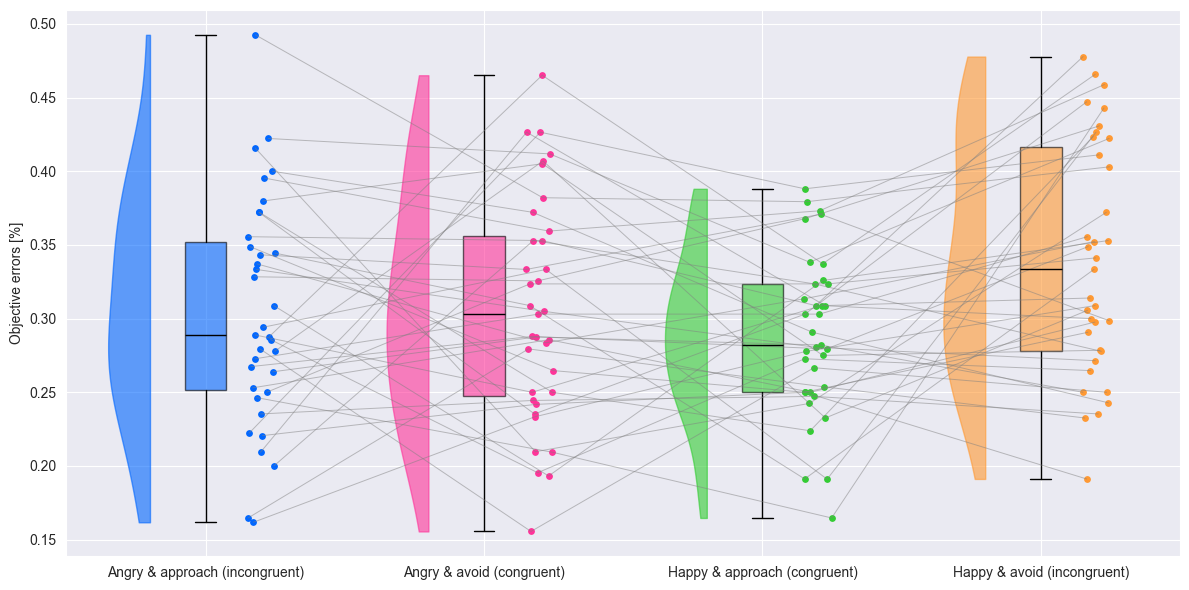

In [61]:
# Comparing overall congruency and volatility performance interaction
# Single-pass aggregation & reshape
combined_results_pivoted = combined_results_dataframe[combined_results_dataframe['volatility'] == 'volatile']
combined_results_pivoted = (
    combined_results_pivoted
    .pivot_table(
        index=['subject_id', 'session'],
        columns=['valence','correct_response_boolean'],
        values='objective_errors',
        aggfunc='mean'
    )
    .reset_index()
)
combined_results_pivoted.columns = [
    f"{a}_{b}" if b else a
    for a, b in combined_results_pivoted.columns
]
print(combined_results_pivoted)

# Plot the four groups using a raincloud plot
utils.plotting_functions.paired_raincloud_4_groups(
    combined_results_pivoted,
    columns=['angry_-1','angry_1','happy_-1','happy_1'],
    labels=['Angry & approach (incongruent)','Angry & avoid (congruent)','Happy & approach (congruent)','Happy & avoid (incongruent)'],
    output_dir=output_dir,
    ylabel_name='Objective errors [%]',
    plot_name='all_trials_objective_errors_volatile_rewarding_responses',
    plot_title='Errors correct response volatile'
)

   subject_id     session  angry_-1   angry_1  happy_-1   happy_1
0     sub-005  session-02  0.172840  0.147727  0.102273  0.207317
1     sub-005  session-03  0.166667  0.261905  0.234568  0.222222
2     sub-005  session-04  0.148936  0.294872  0.294872  0.138298
3     sub-010  session-02  0.360465  0.255814  0.244186  0.202381
4     sub-010  session-03  0.197802  0.217949  0.205128  0.206522
..        ...         ...       ...       ...       ...       ...
30    sub-029  session-03  0.363636  0.310345  0.195402  0.340909
31    sub-029  session-04  0.238636  0.297619  0.204819  0.238636
32    sub-037  session-02  0.231707  0.250000  0.241379  0.190476
33    sub-037  session-03  0.255814  0.252874  0.232558  0.344828
34    sub-037  session-04  0.227273  0.216867  0.296296  0.318182

[35 rows x 6 columns]
plotting is turned off


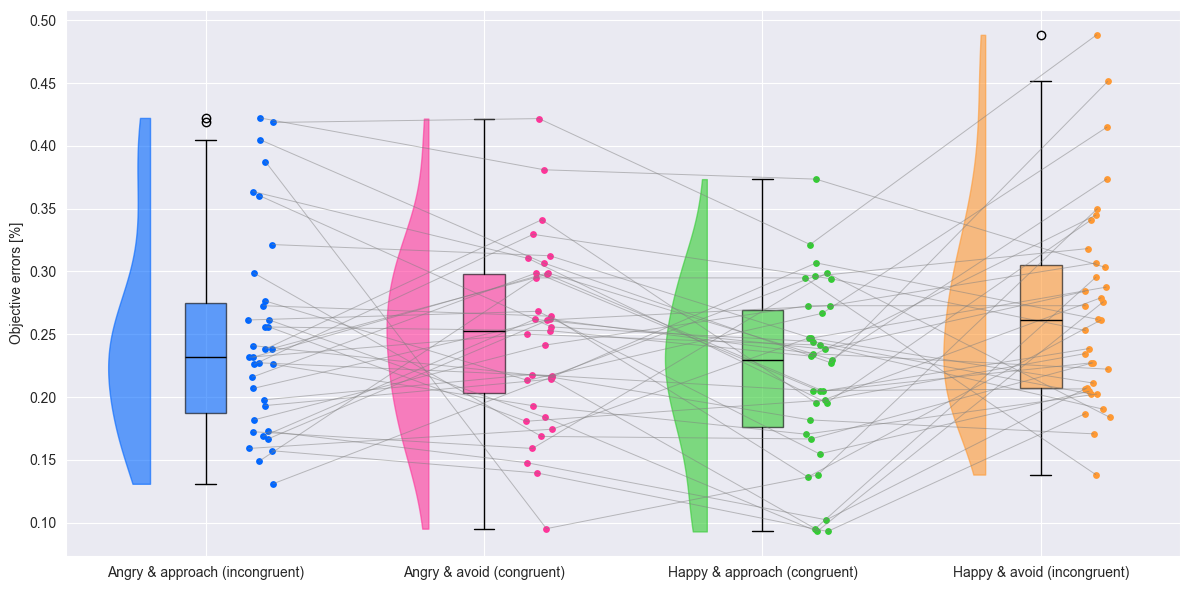

In [62]:
# Comparing overall congruency and volatility performance interaction
# Single-pass aggregation & reshape
combined_results_pivoted = combined_results_dataframe[combined_results_dataframe['volatility'] == 'stable']
combined_results_pivoted = (
    combined_results_pivoted
    .pivot_table(
        index=['subject_id', 'session'],
        columns=['valence','correct_response_boolean'],
        values='objective_errors',
        aggfunc='mean'
    )
    .reset_index()
)
combined_results_pivoted.columns = [
    f"{a}_{b}" if b else a
    for a, b in combined_results_pivoted.columns
]
print(combined_results_pivoted)

# Plot the four groups using a raincloud plot
utils.plotting_functions.paired_raincloud_4_groups(
    combined_results_pivoted,
    columns=['angry_-1','angry_1','happy_-1','happy_1'],
    labels=['Angry & approach (incongruent)','Angry & avoid (congruent)','Happy & approach (congruent)','Happy & avoid (incongruent)'],
    output_dir=output_dir,
    ylabel_name='Objective errors [%]',
    plot_name='all_trials_objective_errors_stable_rewarding_responses',
    plot_title='Errors correct response stable'
)

# Now do the same thing but split them for congruency & volatility

In [63]:
# Check if a block is volatile or stable
dataframe = combined_results_dataframe.sort_values(by=['subject_id', 'session', 'stimuli_type', 'trial'], ascending=[True, True, True, True])

# Create new plots with different intervals that also contain the 50% trials
mapping = {0: 'subject_id', 1: 'stimuli_type', 2: 'congruency', 3: 'volatility', 4: 0, 5: 1, 6: 2, 7: 3, 8: 4, 9: 5, 10: 6}
group_name = 'volatility'
unique_group_types = dataframe[group_name].unique()


dataframe = utils.analysis_functions.find_reversals_in_dataframe(dataframe, unique_subject_ids, unique_stimuli_types,
                                                                'volatility', plot_range, mapping, 'congruency')

#print(dataframe)

      subject_id  trial  stimuli_type  probability_condition  reversal  \
0        sub-005      8             1                     20     False   
1        sub-005     11             1                     20     False   
2        sub-005     12             1                     20     False   
3        sub-005     14             1                     20     False   
4        sub-005     15             1                     20     False   
...          ...    ...           ...                    ...       ...   
22871    sub-037    659             2                     20      True   
22872    sub-037    660             2                     20     False   
22873    sub-037    661             2                     20     False   
22874    sub-037    662             2                     20     False   
22875    sub-037    666             2                     20     False   

      volatility   congruency  
0       volatile    congruent  
1       volatile    congruent  
2       volatil

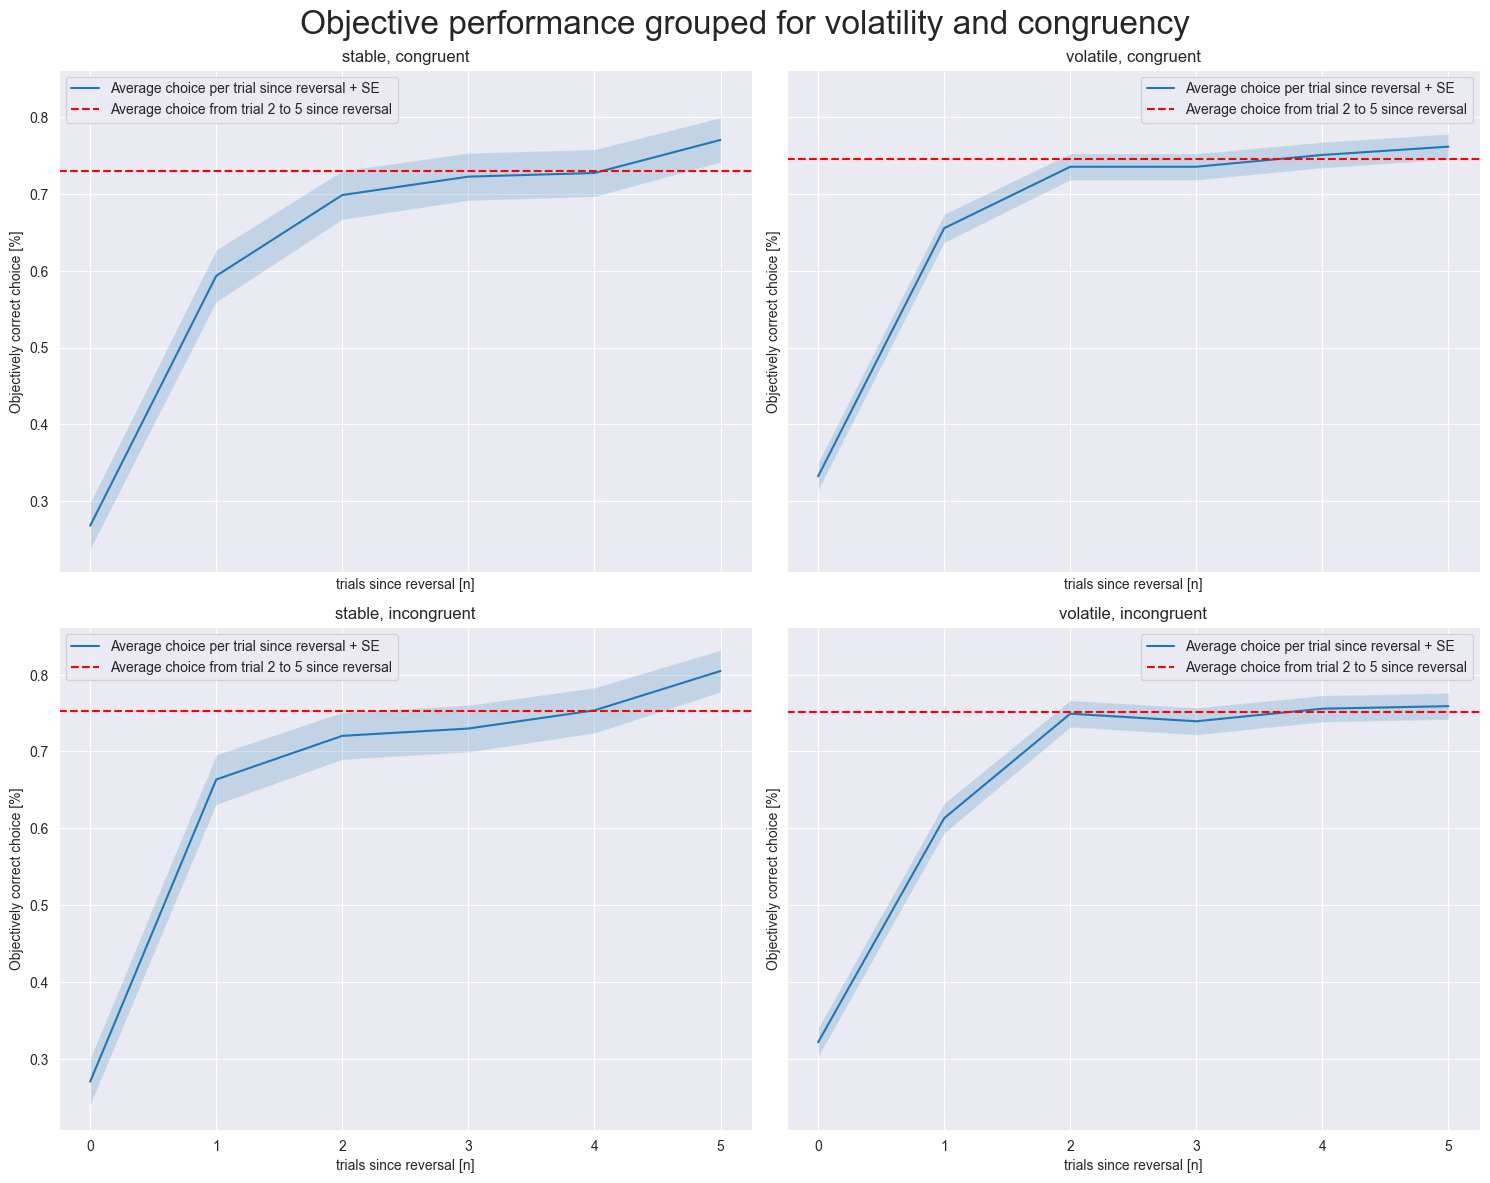

In [64]:
# Prepare the DataFrame by setting 'stimuli_type' as the index temporarily
df = dataframe

# We are not using 'subject_id', so let's exclude it from our calculations
df = df.drop(columns=['subject_id', 'stimuli_type'])

# Calculate the mean and standard deviation for each timepoint and stimuli_type
means = df.groupby(['congruency', 'volatility']).mean()
means_overall = means.iloc[:, 2:]
average_choice_after_reversal_total = means_overall.mean(axis=1).tolist()

stds = df.groupby(['congruency', 'volatility']).sem()

# Plotting
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(15, 12), sharex=True, sharey=True) # Adjust based on the number of stimuli_types
axs = axs.flatten() # Flatten to iterate easily

fig.suptitle('Objective performance grouped for volatility and congruency', fontsize=24, y=0.982)

congruency_list = df['congruency'].unique()
volatility_list = df['volatility'].unique()

congruency_types = means.index
for i, congruency_type in enumerate(congruency_types):
    # Timepoints are the column names converted to integers for x-axis values
    timepoints = list(range(plot_range[0], plot_range[1]))
    mean_values = means.loc[congruency_type]
    std_values = stds.loc[congruency_type]

    axs[i].plot(timepoints, mean_values, label='Average choice per trial since reversal + SE')
    axs[i].fill_between(timepoints, mean_values - std_values, mean_values + std_values, alpha=0.2)
    axs[i].axhline((average_choice_after_reversal_total[i]), color='r', linestyle='--', label='Average choice from trial 2 to 5 since reversal')
    #axs[i].plot(probability_dataframe_pivoted[i+1].dropna())
    axs[i].set_title(f'{congruency_type[1]}, {congruency_type[0]}')
    axs[i].set_xlabel('trials since reversal [n]')
    axs[i].set_ylabel('Objectively correct choice [%]')
    axs[i].legend()
    axs[i].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'objective_performance_grouped_for_volatility_and_congruency.pdf'))
plt.show()

In [65]:
# Now do the same thing but split them for congruency & volatility
# Check if a block is volatile or stable
dataframe = combined_results_dataframe.sort_values(by=['subject_id', 'session', 'stimuli_type', 'trial'],
                                                   ascending=[True, True, True, True])

# Create new plots with different intervals that also contain the 50% trials
mapping = {0: 'subject_id', 1: 'stimuli_type', 2: 'hidden_congruency', 3: 'volatility', 4: 0, 5: 1, 6: 2, 7: 3, 8: 4, 9: 5,
           10: 6}
group_name = 'volatility'
unique_group_types = dataframe[group_name].unique()

dataframe = utils.analysis_functions.find_reversals_in_dataframe(dataframe, unique_subject_ids, unique_stimuli_types,
                                                                 'volatility', plot_range, mapping, 'hidden_congruency')

#print(dataframe)

      subject_id  trial  stimuli_type  probability_condition  reversal  \
0        sub-005      8             1                     20     False   
1        sub-005     11             1                     20     False   
2        sub-005     12             1                     20     False   
3        sub-005     14             1                     20     False   
4        sub-005     15             1                     20     False   
...          ...    ...           ...                    ...       ...   
22871    sub-037    659             2                     20      True   
22872    sub-037    660             2                     20     False   
22873    sub-037    661             2                     20     False   
22874    sub-037    662             2                     20     False   
22875    sub-037    666             2                     20     False   

      volatility hidden_congruency  
0       volatile       incongruent  
1       volatile       incongruent  


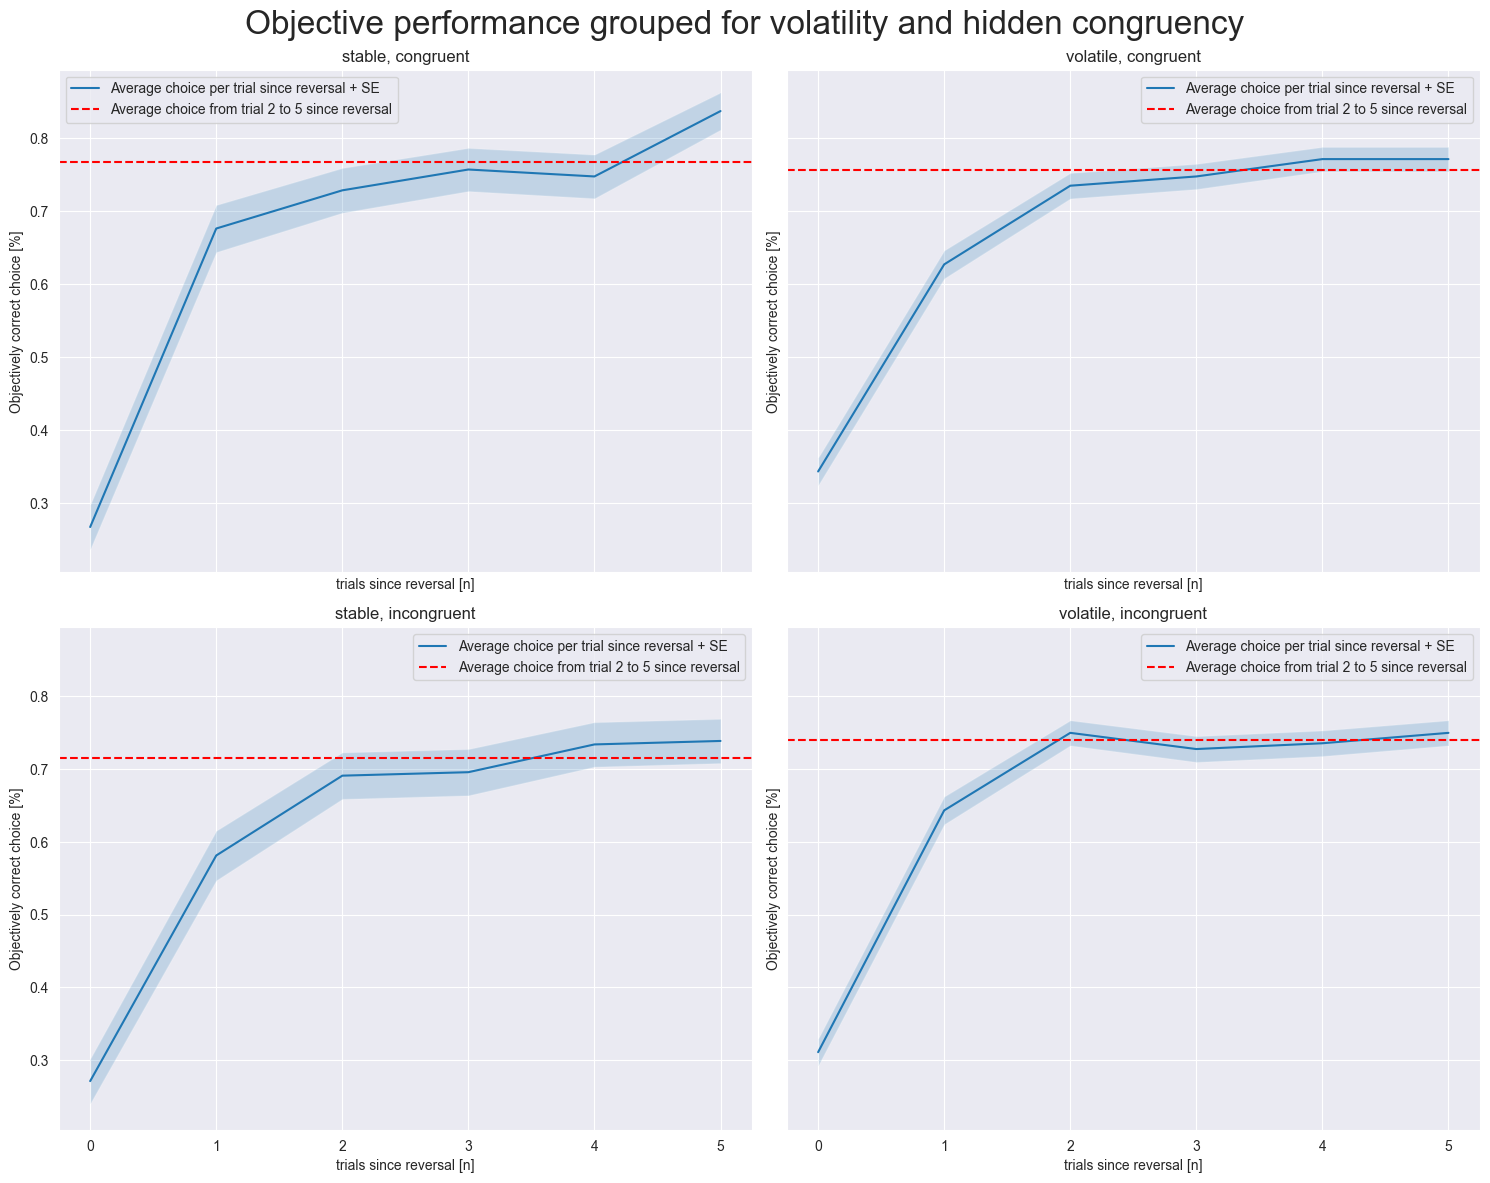

In [66]:
# Prepare the DataFrame by setting 'stimuli_type' as the index temporarily
df = dataframe

# We are not using 'subject_id', so let's exclude it from our calculations
df = df.drop(columns=['subject_id', 'stimuli_type'])

# Calculate the mean and standard deviation for each timepoint and stimuli_type
means = df.groupby(['hidden_congruency', 'volatility']).mean()
means_overall = means.iloc[:, 2:]
average_choice_after_reversal_total = means_overall.mean(axis=1).tolist()

stds = df.groupby(['hidden_congruency', 'volatility']).sem()

# Plotting
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(15, 12), sharex=True, sharey=True) # Adjust based on the number of stimuli_types
axs = axs.flatten() # Flatten to iterate easily

fig.suptitle('Objective performance grouped for volatility and hidden congruency', fontsize=24, y=0.982)

congruency_list = df['hidden_congruency'].unique()
volatility_list = df['volatility'].unique()

congruency_types = means.index
for i, congruency_type in enumerate(congruency_types):
    # Timepoints are the column names converted to integers for x-axis values
    timepoints = list(range(plot_range[0], plot_range[1]))
    mean_values = means.loc[congruency_type]
    std_values = stds.loc[congruency_type]

    axs[i].plot(timepoints, mean_values, label='Average choice per trial since reversal + SE')
    axs[i].fill_between(timepoints, mean_values - std_values, mean_values + std_values, alpha=0.2)
    axs[i].axhline((average_choice_after_reversal_total[i]), color='r', linestyle='--', label='Average choice from trial 2 to 5 since reversal')
    #axs[i].plot(probability_dataframe_pivoted[i+1].dropna())
    axs[i].set_title(f'{congruency_type[1]}, {congruency_type[0]}')
    axs[i].set_xlabel('trials since reversal [n]')
    axs[i].set_ylabel('Objectively correct choice [%]')
    axs[i].legend()
    axs[i].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'objective_performance_grouped_for_volatility_and_hidden_congruency.pdf'))
plt.show()

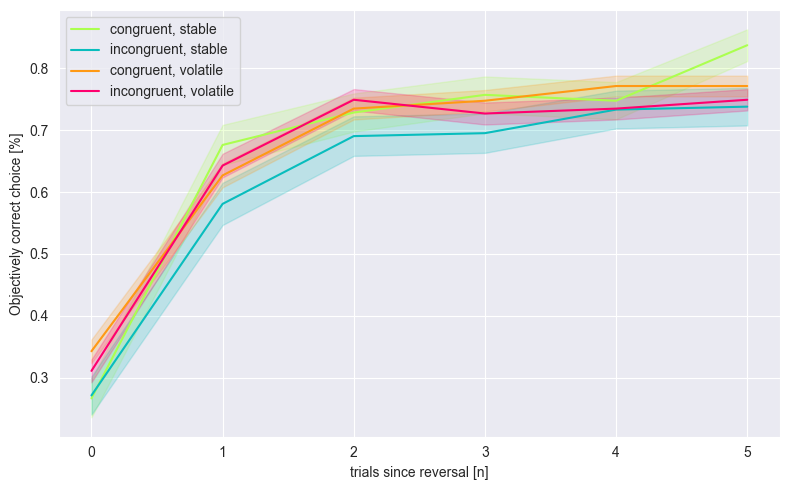

In [70]:
df_long = dataframe.melt(
    id_vars=['subject_id', 'stimuli_type', 'volatility', 'hidden_congruency'],
    value_vars=[0, 1, 2, 3, 4, 5],
    var_name='time',
    value_name='value'
)
# Convert the time column to integers
df_long['time'] = df_long['time'].astype(int)

# Compute mean and standard error of the mean (SEM)
summary = (
    df_long
    .groupby(['volatility', 'hidden_congruency', 'time'])['value']
    .agg(['mean', 'sem'])
    .reset_index()
)

colour = ['#ABFF4F','#08BDBD','#FF9914','#FF006E']

# 3) Plot with shaded error bands
fig, ax = plt.subplots(figsize=(8, 5))
for idx, ((vol, cong), grp) in enumerate(summary.groupby(['volatility', 'hidden_congruency'])):
    x = grp['time']
    y = grp['mean']
    yerr = grp['sem']
    # draw the line
    line, = ax.plot(
        x, y,
        label=f'{cong}, {vol}',
        color=colour[idx],
    )
    # use same colour for the fill, with transparency
    #colour = line.get_color()
    ax.fill_between(
        x,
        y - yerr,
        y + yerr,
        color=colour[idx],
        alpha=0.2
    )

ax.set_xlabel('trials since reversal [n]')
ax.set_ylabel('Objectively correct choice [%]')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'objective_performance_combined_for_volatility_and_hidden_congruency.pdf'))
plt.show()

# Plot the full stable block

In [71]:
# Check if a block is volatile or stable
dataframe = combined_results_dataframe.sort_values(by=['subject_id', 'session', 'stimuli_type', 'trial'], ascending=[True, True, True, True])

# Create a dictionary based on the plot range
initial_columns = {0: 'subject_id', 1: 'stimuli_type', 2: 'volatility'}
adjusted_plot_range = [0, 28]
# Append the plot range to the existing dictionary
mapping = initial_columns.copy()
mapping.update({k+3: v for k, v in enumerate(plot_range)})

# Define the to be plotted factor
group_name = 'volatility'
unique_group_types = dataframe[group_name].unique()

dataframe = utils.analysis_functions.find_reversals_in_dataframe(dataframe, unique_subject_ids, unique_stimuli_types,
                                                                'volatility', adjusted_plot_range, mapping)

print(dataframe)

      subject_id  trial  stimuli_type  probability_condition  reversal  \
0        sub-005      8             1                     20     False   
1        sub-005     11             1                     20     False   
2        sub-005     12             1                     20     False   
3        sub-005     14             1                     20     False   
4        sub-005     15             1                     20     False   
...          ...    ...           ...                    ...       ...   
22871    sub-037    659             2                     20      True   
22872    sub-037    660             2                     20     False   
22873    sub-037    661             2                     20     False   
22874    sub-037    662             2                     20     False   
22875    sub-037    666             2                     20     False   

      volatility  
0       volatile  
1       volatile  
2       volatile  
3       volatile  
4       volatile

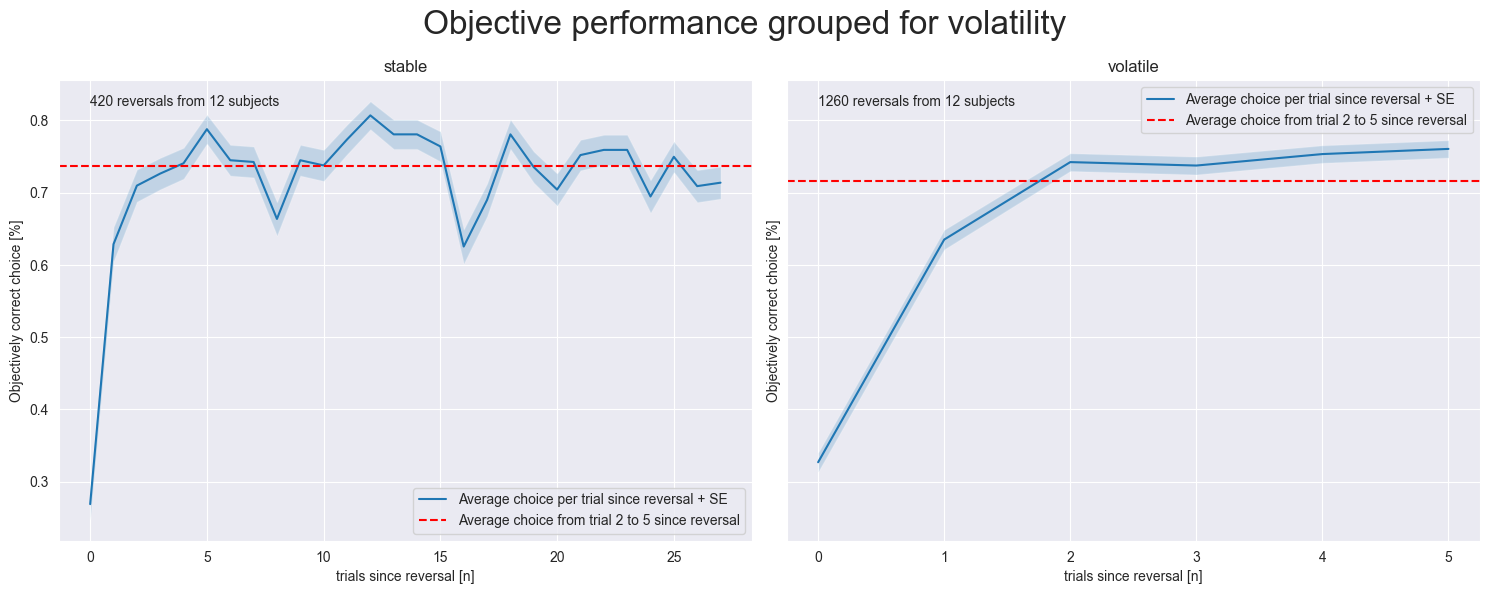

In [72]:
# Remove volatile rows
df = dataframe.set_index('volatility')

subject_counts = len(df['subject_id'].unique())

# Count the number of times both conditions were shown
group_counts = df.index.value_counts()

# We are not using 'subject_id', so let's exclude it from our calculations
df = df.drop(columns=['subject_id'])
df = df.drop(columns=['stimuli_type'])

# Calculate the mean and standard deviation for each timepoint and stimuli_type
means = df.groupby('volatility').mean()
means_overall = means.iloc[:, 2:]
average_choice_after_reversal_total = (means_overall.mean(axis=1).tolist())
stds = df.groupby('volatility').sem()

# Plotting
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 6), sharex=False, sharey=True) # Adjust based on the number of stimuli_types
axs = axs.flatten() # Flatten to iterate easily

fig.suptitle('Objective performance grouped for volatility', fontsize=24, y=0.982)

congruency_list = dataframe['volatility'].unique()

congruency_types = means.index
for i, congruency_type in enumerate(congruency_types):
    # Timepoints are the column names converted to integers for x-axis values

    mean_values = means.loc[congruency_type]
    std_values = stds.loc[congruency_type]
    
    if congruency_type == 'stable':
        timepoints = list(range(adjusted_plot_range[0], adjusted_plot_range[1]))
    else:
        volatile_duration = 6
        timepoints = list(range(0, volatile_duration))
        mean_values = mean_values.iloc[:volatile_duration]
        std_values = std_values.iloc[:volatile_duration]

    axs[i].plot(timepoints, mean_values, label='Average choice per trial since reversal + SE')
    axs[i].fill_between(timepoints, mean_values - std_values, mean_values + std_values, alpha=0.2)
    axs[i].axhline(average_choice_after_reversal_total[i], color='r', linestyle='--', label='Average choice from trial 2 to 5 since reversal')
    #axs[i].plot(probability_dataframe_pivoted[i+1].dropna())
    axs[i].set_title(congruency_list[i])
    axs[i].set_xlabel('trials since reversal [n]')
    axs[i].set_ylabel('Objectively correct choice [%]')
    axs[i].text(0, 0.82, f'{group_counts[congruency_type]} reversals from {subject_counts} subjects', fontsize=10)
    axs[i].legend()
    axs[i].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'objective_performance_for_full_stable_block.pdf'))
plt.show()

In [78]:
# Check if a block is volatile or stable
dataframe = combined_results_dataframe.sort_values(by=['subject_id', 'session', 'stimuli_type', 'trial'], ascending=[True, True, True, True])

# Then bin the area around a reversal
adjusted_plot_range = [plot_range[0] - plot_range[1], plot_range[1] - 1]
dataframe = utils.analysis_functions.bin_responses_for_congruency(dataframe, adjusted_plot_range, 'volatility')

# Map transitions to congruency
to_flip = {
    'happy_congruent_to_incongruent',
    'happy_incongruent_to_congruent'
}

# build a boolean mask for rows to flip
mask = dataframe['emotional_valence_and_transition'].isin(to_flip)

# apply the flip
dataframe.loc[mask, 'response_int'] = 100 - dataframe.loc[mask, 'response_int']

# define your mapping
mapping = {
    'angry_congruent_to_incongruent':    'congruent_to_incongruent',
    'happy_incongruent_to_congruent':    'incongruent_to_congruent',
    'angry_incongruent_to_congruent':    'incongruent_to_congruent',
    'happy_congruent_to_incongruent':    'congruent_to_incongruent',
    'angry_no_transition':               'no_transition',
    'happy_no_transition':               'no_transition',
}

# create new column
dataframe['transitions_combined'] = (
    dataframe['emotional_valence_and_transition']
     .map(mapping)
     .fillna('unknown')   # optional: catch any unexpected values
)

print(dataframe)

[0, 30, 62, 68, 76, 82, 90, 96, 106, 138, 166, 174, 183, 189, 195, 205, 213, 242, 270, 276, 286, 293, 303, 311, 321, 327, 357, 389, 395, 403, 409, 417, 423, 433, 465, 493, 501, 511, 517, 523, 532, 540, 570, 598, 604, 614, 622, 632, 640, 650, 686, 716, 722, 732, 742, 749, 759, 765, 797, 829, 837, 847, 853, 861, 871, 879, 907, 935, 945, 951, 957, 965, 973, 979, 985, 1014, 1044, 1050, 1060, 1070, 1078, 1088, 1094, 1125, 1157, 1164, 1174, 1180, 1188, 1198, 1206, 1233, 1261, 1271, 1277, 1283, 1291, 1299, 1305, 1311, 1321, 1331, 1339, 1347, 1355, 1361, 1389, 1419, 1429, 1439, 1449, 1457, 1463, 1471, 1501, 1533, 1539, 1545, 1553, 1563, 1569, 1575, 1603, 1635, 1641, 1651, 1661, 1669, 1677, 1685, 1691, 1719, 1749, 1759, 1769, 1779, 1787, 1793, 1801, 1831, 1863, 1869, 1875, 1883, 1893, 1899, 1905, 1933, 1965, 1971, 1981, 1987, 1997, 2003, 2011, 2021, 2053, 2083, 2091, 2099, 2105, 2115, 2122, 2130, 2160, 2188, 2196, 2202, 2212, 2222, 2228, 2234, 2266, 2294, 2300, 2310, 2315, 2325, 2331, 2339, 234

# Still needs fix where only transitions of volatile to volatile and stable to stable are used

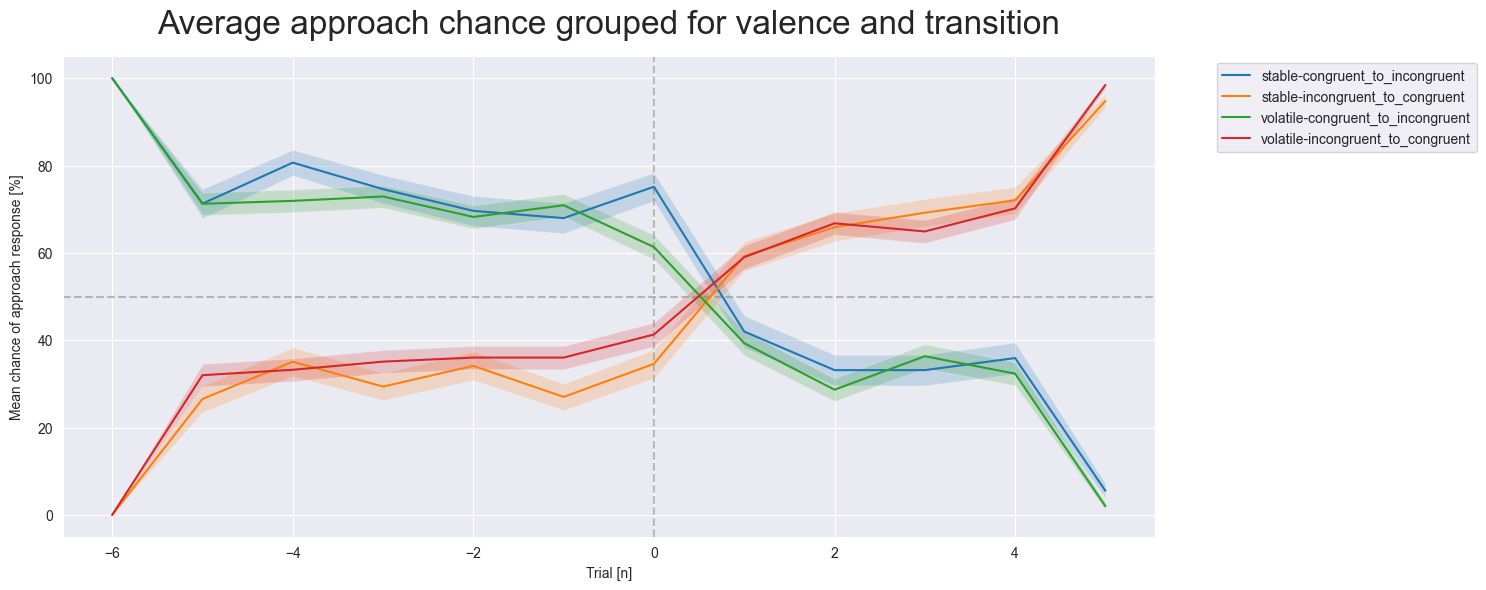

In [79]:
# Group the data
grouped_dataframe = dataframe.groupby(['trials_around_reversal', 'volatility', 'transitions_combined'])['response_int'].agg(['mean', 'sem']).reset_index()

# Plotting with Matplotlib
plt.figure(figsize=(15, 6))

# Define the unique groups for 'emotional_valence' and 'transition'
emotional_valences = grouped_dataframe['volatility'].unique()
transitions = grouped_dataframe['transitions_combined'].unique()
transitions = [s for s in transitions if 'no_transition' not in s]

# Plot each group
plt.axhline(50, color='grey', linestyle='dashed', alpha=0.5)
plt.axvline(0, color='grey', linestyle='dashed', alpha=0.5)
for valence in emotional_valences:
    for transition in transitions:
        subset = grouped_dataframe[(grouped_dataframe['volatility'] == valence) & (grouped_dataframe['transitions_combined'] == transition)]
        current_emotion = subset['volatility'].unique()
        current_transition = subset['transitions_combined'].unique()
        if not subset.empty:
            plt.plot(subset['trials_around_reversal'], subset['mean'], label=f'{valence}-{transition}')
            plt.fill_between(subset['trials_around_reversal'], subset['mean'] - subset['sem'], subset['mean'] + subset['sem'], alpha=0.2)

# Customize the plot
plt.xlabel('Trial [n]')
plt.ylabel('Mean chance of approach response [%]')
plt.title('Average approach chance grouped for valence and transition', fontsize=24, y=1.03)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()

plt.savefig(os.path.join(output_dir, 'average_approach_chance_grouped_for_volatility_and_transition.pdf'))
# Show the plot
plt.show()

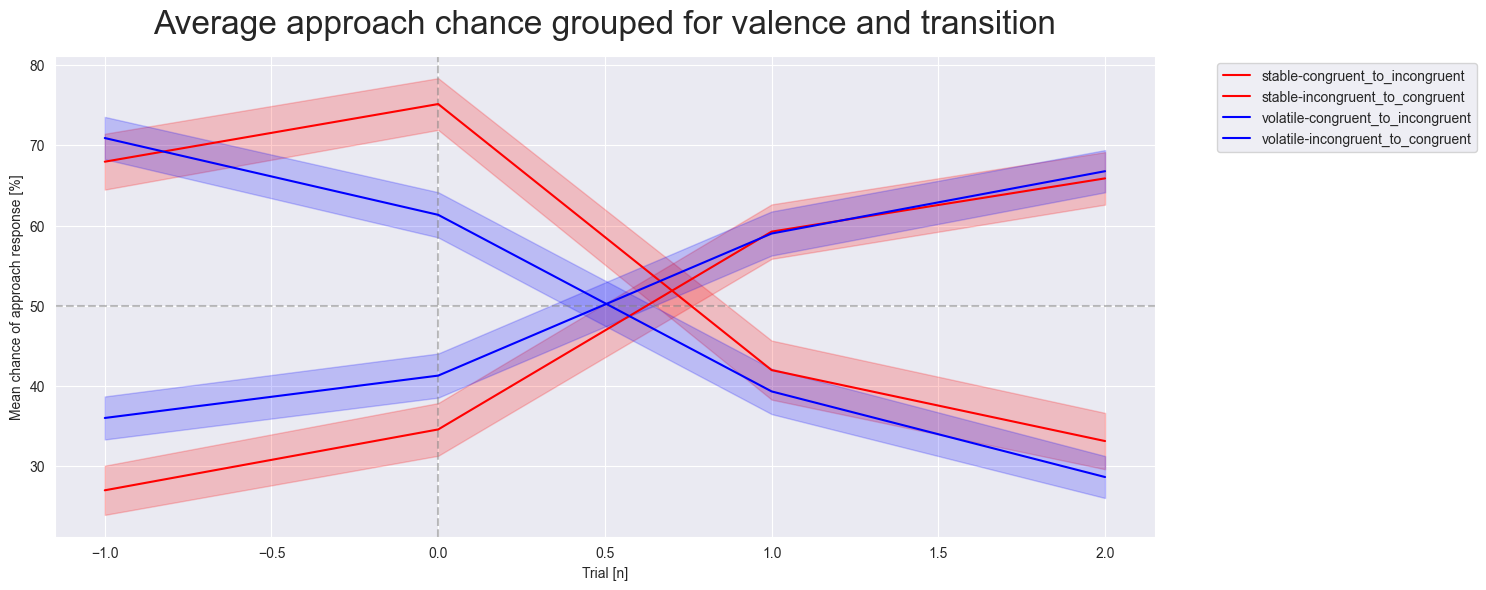

In [82]:
# Zoom in on the window from trial -1 to 2
subset_dataframe = dataframe[(dataframe['trials_around_reversal'] >= -1) &
                      (dataframe['trials_around_reversal'] <= 2)]

# Group the data
grouped_dataframe = subset_dataframe.groupby(['trials_around_reversal', 'volatility', 'transitions_combined'])['response_int'].agg(['mean', 'sem']).reset_index()

# Plotting with Matplotlib
plt.figure(figsize=(15, 6))

# Define the unique groups for 'emotional_valence' and 'transition'
emotional_valences = grouped_dataframe['volatility'].unique()
transitions = grouped_dataframe['transitions_combined'].unique()
transitions = [s for s in transitions if 'no_transition' not in s]

colors = ['red', 'red', 'blue', 'blue']
color_index = 0

# Plot each group
plt.axhline(50, color='grey', linestyle='dashed', alpha=0.5)
plt.axvline(0, color='grey', linestyle='dashed', alpha=0.5)
for valence in emotional_valences:
    for transition in transitions:
        subset = grouped_dataframe[(grouped_dataframe['volatility'] == valence) & (grouped_dataframe['transitions_combined'] == transition)]
        current_emotion = subset['volatility'].unique()
        current_transition = subset['transitions_combined'].unique()
        if not subset.empty:
            plt.plot(subset['trials_around_reversal'], subset['mean'], label=f'{valence}-{transition}', color=colors[color_index])
            plt.fill_between(subset['trials_around_reversal'], subset['mean'] - subset['sem'], subset['mean'] + subset['sem'], alpha=0.2, color=colors[color_index])

        color_index += 1

# Customize the plot
plt.xlabel('Trial [n]')
plt.ylabel('Mean chance of approach response [%]')
plt.title('Average approach chance grouped for valence and transition', fontsize=24, y=1.03)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()

plt.savefig(os.path.join(output_dir, 'average_approach_chance_grouped_for_volatility_and_transition_zoomed.pdf'))
# Show the plot
plt.show()

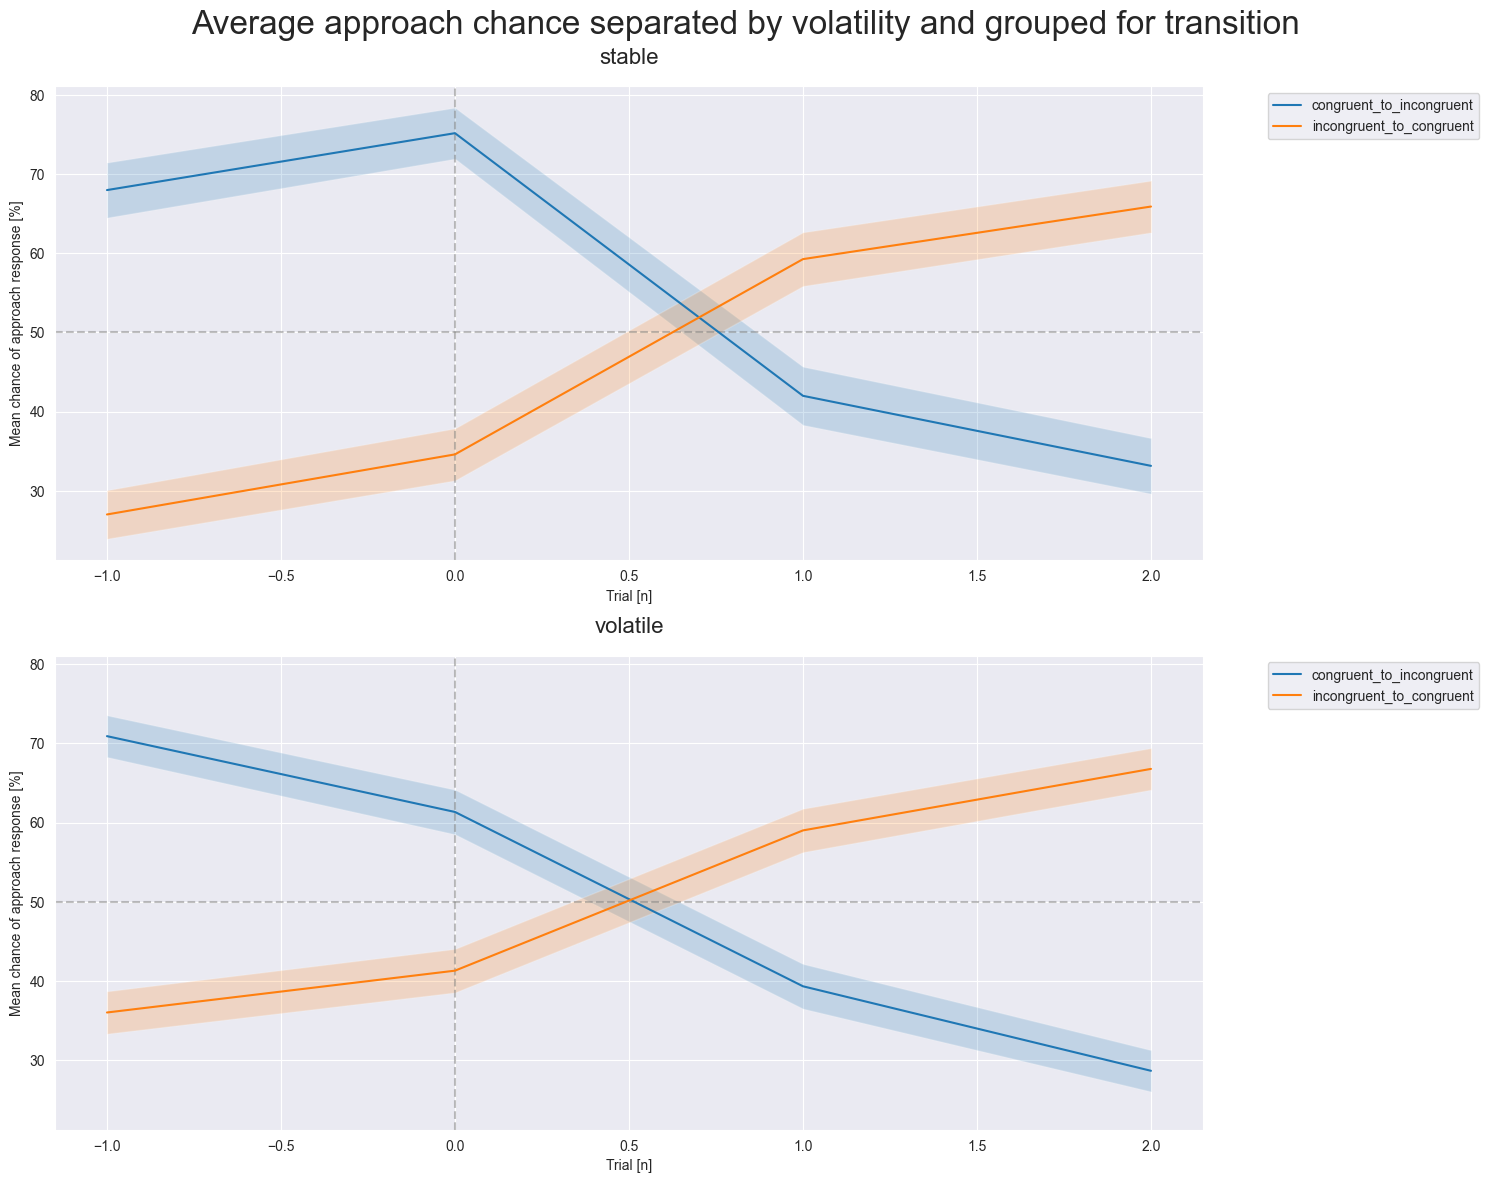

In [76]:
# Plotting with Matplotlib
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(15, 12), sharey=True)

fig.suptitle('Average approach chance separated by volatility and grouped for transition', fontsize=24, y=0.982)

# Plot each group
for valence_index, valence_value in enumerate(emotional_valences):
    axes[valence_index].axhline(50, color='grey', linestyle='dashed', alpha=0.5)
    axes[valence_index].axvline(0, color='grey', linestyle='dashed', alpha=0.5)
    for transition in transitions:
        subset = grouped_dataframe[(grouped_dataframe['volatility'] == valence_value) & (grouped_dataframe['transitions_combined'] == transition)]
        current_emotion = subset['volatility'].unique()
        current_transition = subset['transitions_combined'].unique()
        if not subset.empty:
            axes[valence_index].plot(subset['trials_around_reversal'], subset['mean'], label=f'{transition}')
            axes[valence_index].fill_between(subset['trials_around_reversal'], subset['mean'] - subset['sem'], subset['mean'] + subset['sem'], alpha=0.2)

    # Customize the plot
    axes[valence_index].set_xlabel('Trial [n]')
    axes[valence_index].set_ylabel('Mean chance of approach response [%]')
    axes[valence_index].set_title(valence_value, fontsize=16, y=1.03)
    axes[valence_index].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.grid(True)
plt.tight_layout()

plt.savefig(os.path.join(output_dir, 'average_approach_chance_separated_by_volatility_and_grouped_for_transition.pdf'))
# Show the plot
plt.show()

# Overall objective performance over time
This will be used to check whether their performance stabilises after the 1st session

In [48]:
all_session_labels = ['session-01', 'session-02', 'session-03', 'session-04']
if all(s in unique_sessions for s in all_session_labels):
    # Check if a block is volatile or stable
    dataframe = combined_results_dataframe_all_sessions[combined_results_dataframe_all_sessions['probability_condition'] != 50]
    dataframe = utils.analysis_functions.check_volatility(dataframe)
    dataframe = dataframe.sort_values(by=['subject_id', 'session', 'stimuli_type', 'trial'], ascending=[True, True, True, True])

    # Single-pass aggregation & reshape
    combined_results_pivoted = dataframe[dataframe['trials_since_reversal'] != 0]
    combined_results_pivoted = (
        combined_results_pivoted
        .pivot_table(
            index=['subject_id', 'session'],
            columns=['congruency', 'volatility'],
            values='objectively_correct_boolean',
            aggfunc='mean'
        )
        .reset_index()
    )
    combined_results_pivoted.columns = [
        f"{a}_{b}" if b else a
        for a, b in combined_results_pivoted.columns
    ]
    print(combined_results_pivoted)

    # Plot the two groups using a raincloud plot
    utils.plotting_functions.paired_scatter_violin_box_2x2(
        combined_results_pivoted,
        columns=['congruent_stable','incongruent_stable','congruent_volatile','incongruent_volatile'],
        subject_col='subject_id',
        session_col='session',
        labels=['Stable & congruent','Stable & incongruent','Volatile & congruent','Volatile & incongruent'],
        output_dir=output_dir,
        ylabel_name='Objectively correct choice [%]',
        plot_name='all_trials_objective_performance_comparing_congruency_and_volatility'
    )